# Sheet Eval

## Configuration selon l'environnement

Ce notebook tourne **en local (VS Code)** et **sur Google Colab** sans modification.
La variable `IN_COLAB` est detecee automatiquement (cellule Installation + Auth).

---

### Sur Google Colab uniquement

Les elements suivants s'activent automatiquement quand `IN_COLAB = True` :

- **Auth Google Sheets** : `google.colab.auth.authenticate_user()` — ouvre le popup OAuth Colab
- **Installation des packages** : `pip install gspread google-auth ...` — execute a chaque session Colab
- **Poll du Sheet** : `poll_one()` attend `TOTAL_Q` lignes (utile si le batch tourne en parallele)
- **Telechargement des exports** : `google.colab.files.download(fname)` dans `show_details()`

### En local (VS Code) uniquement

- **Auth Google Sheets** : `gspread.oauth()` lit `credentials.json` + `token.json` a la racine du projet
  - Prérequis : avoir fait `gspread.oauth()` une premiere fois (ouvre le navigateur)
- Les packages doivent etre installes dans ton venv : `pip install -e '.[eval]'`
- `poll_one()` lit le Sheet directement sans attendre (le batch est deja termine)

### Parametre a regler avant d'executer

Dans la cellule **Manual Config** (juste apres) :
```python
SHEET_ID     = '...'          # ID de ton Google Sheet
SHEET_NAMES  = ['onglet1']    # nom(s) de l'onglet a lire
SCENARIOS    = ['label1']     # label affiche dans les graphes
TOTAL_TIMES  = [0]            # 0 = utiliser latency_s du Sheet
```


## Golden Dataset

In [47]:
GOLDEN_DATASET = [
    {"id":"Q0001","question":"URGENT faut creer une commande client jen ai besoin la tout de suite cest quoi lapi ?","expected_apis":["order-api-v4"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"urgent","phrasing":"question_directe"},
    {"id":"Q0002","question":"je veux fetch le profil du user qui vient de se log, quelle api ?","expected_apis":["auth-api"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0003","question":"Salut, je bosse sur le nouveau site e-commerce de ma boite et le PO veut une barre de recherche avec de l'autocomplete sur les produits, tu connais l'api qui fait ça ?","expected_apis":["search-api-v3"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0004","question":"URGENT faut alerter auto qd le stock dun produit passe sous le seuil min, on est en rupture la","expected_apis":["inventory-api"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0005","question":"Je dois afficher le prix d'un produit avec les promos appliquées, quelle API utiliser ?","expected_apis":["pricing-api"],"category":"simple","domain":"ecommerce","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0006","question":"je veux fetch le profil du user qui vient de se log, quelle api ?","expected_apis":["auth-api"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0007","question":"le user clique sur 'add to cart', japelle quelle api ?","expected_apis":["cart-api"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0008","question":"besoin denvoyer une notif push qd la commande est shippée, vite cest pour la demo","expected_apis":["notification-api-v3"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0009","question":"Bonjour, on a plein de clients qui nous appellent pour savoir où est leur colis, du coup je veux intégrer un tracking de livraison dans l'app, c'est quelle api ?","expected_apis":["logistics-tracking-api"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0010","question":"jveux permettre aux clients de laisser une note et un commentaire sur un produit","expected_apis":["review-api"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0011","question":"apres le paiement faut generer la facture pdf automatiquement, cest quel api","expected_apis":["invoice-api-v3"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0012","question":"Notre équipe achats veut créer des bons de commande fournisseurs dans le système","expected_apis":["purchase-order-api"],"category":"simple","domain":"ecommerce","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0013","question":"Je veux ajouter une fonctionnalité liste de souhaits sur mon appli mobile","expected_apis":["wishlist-api"],"category":"simple","domain":"ecommerce","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0014","question":"Un client veut retourner un produit et être remboursé, quelle API gère ça côté Commerce ?","expected_apis":["return-api"],"category":"simple","domain":"ecommerce","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0015","question":"le client tape un promo code genre SOLDES20, comment japplique le discount sur sa commande ?","expected_apis":["pricing-api"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0016","question":"L'équipe marketing veut lancer une campagne email pour les soldes","expected_apis":["campaign-api"],"category":"simple","domain":"ecommerce","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0017","question":"Je dois afficher le solde de points fidélité d'un client sur son profil","expected_apis":["loyalty-points-api"],"category":"simple","domain":"ecommerce","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0018","question":"Je mets en place un abonnement mensuel à une box, quelle API gère la récurrence ?","expected_apis":["subscription-api"],"category":"simple","domain":"ecommerce","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0019","question":"le client veut payer avec son wallet de crédits sur la plateforme, cest quoi lapi","expected_apis":["wallet-api"],"category":"simple","domain":"ecommerce","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0020","question":"Un client ouvre un ticket SAV pour un produit défectueux, quelle API gère ça ?","expected_apis":["ticket-api"],"category":"simple","domain":"ecommerce","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0021","question":"Je veux gérer mon catalogue produit, pas juste faire une recherche dedans","expected_apis":["product-catalog-api"],"category":"faux_positif","domain":"ecommerce","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0022","question":"On me dit d'utiliser l'API analytics mais moi je veux juste générer des rapports PDF planifiés","expected_apis":["reporting-api-v2"],"category":"faux_positif","domain":"ecommerce","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0023","question":"Le client veut être remboursé après annulation de commande, mais c'est pas l'API order que je cherche","expected_apis":["payment-api-v3"],"category":"faux_positif","domain":"ecommerce","difficulty":"medium","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0024","question":"Je veux envoyer des emails transactionnels de confirmation, pas des SMS ni des push","expected_apis":["email-api"],"category":"faux_positif","domain":"ecommerce","difficulty":"medium","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0025","question":"J'ai besoin de vérifier le 2FA d'un utilisateur à la connexion, c'est pas l'auth classique","expected_apis":["mfa-api"],"category":"faux_positif","domain":"ecommerce","difficulty":"medium","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0026","question":"faut creer un dossier patient a ladmission au format HL7 FHIR, quel api ?","expected_apis":["patient-api-v3"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0027","question":"Je dois migrer depuis patient-api-v1 qui ne sera plus maintenue, quelle version je prends ?","expected_apis":["patient-api-v3"],"category":"versioning","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0028","question":"Bonjour, je développe le logiciel de notre clinique. Quand le médecin termine sa consultation et pose un diagnostic, on doit l'enregistrer dans le dossier médical du patient. Vous avez une api pour ça ?","expected_apis":["medical-record-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0029","question":"jveux vérifier si deux médicaments sont compatibles avant de créer l'ordonnance","expected_apis":["drug-interaction-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0030","question":"Les résultats de prise de sang du patient sont revenus du labo, où je les enregistre ?","expected_apis":["lab-result-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0031","question":"URGENT faut monitorer les vital signs (tension pouls) d'un patient en réa en temps réel","expected_apis":["vital-signs-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0032","question":"Le patient veut une téléconsultation avec son médecin depuis chez lui","expected_apis":["telemedicine-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0033","question":"L'infirmière a besoin de savoir quels lits sont disponibles dans le service","expected_apis":["hospital-bed-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0034","question":"La pharmacie hospitalière doit manage son stock de médicaments et les périmés","expected_apis":["pharmacy-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0035","question":"je doit enregistrer le vaccin anti grippe dun patient dans son carnet","expected_apis":["vaccination-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0036","question":"Le patient est allergique à la pénicilline, où j'enregistre ça pour les alertes ?","expected_apis":["allergy-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0037","question":"Le médecin veut créer un plan de soins sur 3 mois pr son patient diabétique","expected_apis":["care-plan-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0038","question":"faut intégrer les images IRM dans le dossier patient, quelle API gère l'imagerie ?","expected_apis":["radiology-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0039","question":"On doit programmer le bloc opératoire pour une intervention la semaine prochaine","expected_apis":["surgery-scheduling-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0040","question":"Je veux inscrire un patient volontaire dans un essai clinique en cours","expected_apis":["clinical-trial-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0041","question":"Salut, je bosse aux urgences d'un CHU. Quand un patient arrive je dois l'enregistrer et lui attribuer un niveau de priorité CCMU pour le triage. C'est quelle api ?","expected_apis":["emergency-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0042","question":"Je surveille un patient à domicile avec des capteurs connectés, quelle API recueille les données ?","expected_apis":["health-monitoring-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0043","question":"Le patient sort de l'hôpital, faut générer son document de sortie avec les ordonnances","expected_apis":["discharge-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0044","question":"Avant la consultation je dois vérifier si le patient est bien couvert par sa mutuelle","expected_apis":["insurance-eligibility-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0045","question":"je veux que l'IA suggère des diagnostics CIM-11 en fonction des symptoms du patient","expected_apis":["diagnosis-api"],"category":"simple","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0046","question":"Le généraliste veut orienter son patient vers un cardiologue, comment ça marche ?","expected_apis":["referral-health-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0047","question":"Je dois admettre un patient pour une chirurgie programmée demain matin","expected_apis":["patient-admission-api"],"category":"simple","domain":"healthcare","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0048","question":"Quelle est la version active de l'API ordonnances électroniques avec signature numérique ?","expected_apis":["prescription-api-v2"],"category":"versioning","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0049","question":"Je cherche l'API d'admission mais je veux pas créer un dossier médical complet, juste le check-in","expected_apis":["patient-admission-api"],"category":"faux_positif","domain":"healthcare","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0050","question":"J'ai les résultats d'analyse mais c'est pas des constantes vitales, c'est des marqueurs biologiques","expected_apis":["lab-result-api"],"category":"faux_positif","domain":"healthcare","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0051","question":"Je dois créer l'ordonnance finale, pas juste vérifier les interactions médicamenteuses","expected_apis":["prescription-api-v2"],"category":"faux_positif","domain":"healthcare","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0052","question":"Je veux vérifier les droits santé d'un patient, pas gérer son contrat d'assurance","expected_apis":["insurance-eligibility-api"],"category":"faux_positif","domain":"healthcare","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0053","question":"Je dois enregistrer une radio thoracique, c'est pas des analyses biologiques de labo","expected_apis":["radiology-api"],"category":"faux_positif","domain":"healthcare","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0054","question":"Je veux poser un diagnostic IA, pas juste enregistrer des actes dans le dossier médical","expected_apis":["diagnosis-api"],"category":"faux_positif","domain":"healthcare","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0055","question":"Je dois migrer de bank-account-api-v1, vers quelle version je passe ?","expected_apis":["bank-account-api-v3"],"category":"versioning","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0056","question":"Je viens de migrer de loan-api-v1, est-ce que la v3 est la bonne cible ?","expected_apis":["loan-api-v3"],"category":"versioning","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0057","question":"Quelle est la version active de l'API prêts immobiliers ?","expected_apis":["mortgage-api-v2"],"category":"versioning","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0058","question":"Quelle est la version active de l'API KYC pour la vérification d'identité ?","expected_apis":["kyc-api-v2"],"category":"versioning","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0059","question":"Quelle est la version active de l'API virements SEPA ?","expected_apis":["transfer-api-v2"],"category":"versioning","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0060","question":"besoin urgent de scorer le risque credit dun client avant daccorder le pret, cest quoi lapi","expected_apis":["credit-scoring-api"],"category":"simple","domain":"banking","difficulty":"medium","register":"urgent","phrasing":"question_directe"},
    {"id":"Q0061","question":"Bonjour, on est une néobanque et un client vient de se faire voler sa carte. Il faut qu'on puisse faire opposition immédiatement depuis le back-office. Quelle api gère les cartes ?","expected_apis":["card-management-api"],"category":"simple","domain":"banking","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0062","question":"je dois détecter en real-time si une transaction est fraud, quelle api ?","expected_apis":["fraud-detection-api"],"category":"simple","domain":"banking","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0063","question":"On doit faire une déclaration TRACFIN pr une opération suspecte","expected_apis":["aml-api"],"category":"simple","domain":"banking","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0064","question":"Le client veut voir tous ses comptes de diff banques en un seul endroit PSD2","expected_apis":["open-banking-api"],"category":"simple","domain":"banking","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0065","question":"faut manage l'ouverture d'un Livret A et d'un PEL pr un client","expected_apis":["savings-api"],"category":"simple","domain":"banking","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0066","question":"Quelle est la version active de l'API trading d'instruments financiers ?","expected_apis":["trading-api-v2"],"category":"versioning","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0067","question":"avant de faire un virement faut verifier que liban du destinataire est valide","expected_apis":["iban-validation-api"],"category":"simple","domain":"banking","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0068","question":"On a besoin des taux EURIBOR et BCE pour nos calculs de prêts variables","expected_apis":["interest-rate-api"],"category":"simple","domain":"banking","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0069","question":"faut calculer la performance et la valorisation du portefeuille actions d'un client","expected_apis":["portfolio-api"],"category":"simple","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0070","question":"Notre conseiller patrimoine veut faire un bilan fiscal complet pour un client","expected_apis":["wealth-api"],"category":"simple","domain":"banking","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0071","question":"Je veux détecter la fraude sur un sinistre assurance, pas sur une transaction bancaire","expected_apis":["fraud-claims-api"],"category":"faux_positif","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0072","question":"Je veux faire un virement vers un fournisseur externe, c'est pas le même que payer un client","expected_apis":["payout-api"],"category":"faux_positif","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0073","question":"Je fais du KYC pour vérifier l'identité, mais c'est pas la surveillance AML ongoing","expected_apis":["kyc-api-v2"],"category":"faux_positif","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0074","question":"Je veux passer des ordres de bourse, pas gérer un portefeuille au sens large","expected_apis":["trading-api-v2"],"category":"faux_positif","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0075","question":"Je veux investir dans des fonds, pas acheter des actions en bourse directement","expected_apis":["investment-api"],"category":"faux_positif","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0076","question":"Je cherche les taux d'intérêt du marché, pas le taux de change EUR/USD","expected_apis":["interest-rate-api"],"category":"faux_positif","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0077","question":"Je veux voir les performances de mon portefeuille, pas gérer mes placements en fonds","expected_apis":["portfolio-api"],"category":"faux_positif","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0078","question":"Quelle est la version active de l'API compteurs intelligents multi-fluides ?","expected_apis":["smart-meter-api-v2"],"category":"versioning","domain":"iot","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0079","question":"faut détecter une fuite d'eau sur le réseau de distribution","expected_apis":["water-meter-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0080","question":"Quelle est la version active de l'API données capteurs IoT ?","expected_apis":["sensor-data-api-v2"],"category":"versioning","domain":"iot","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0081","question":"Salut, on a déployé 500 capteurs sur des machines indus et ils envoient de la télémétrie en continu (température, vibration...). Je cherche l'api qui ingère toute cette data.","expected_apis":["sensor-data-api-v2"],"category":"simple","domain":"iot","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0082","question":"jveux analyser la consommation électrique d'un bâtiment de bureaux","expected_apis":["energy-consumption-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0083","question":"Mon installation solaire produit de l'énergie, je dois gérer la production et l'injection réseau","expected_apis":["solar-panel-api"],"category":"simple","domain":"iot","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0084","question":"Quelle est la version active de l'API bornes de recharge pour véhicules électriques ?","expected_apis":["ev-charging-api-v2"],"category":"versioning","domain":"iot","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0085","question":"jveux programmer le chauffage et la clim du bâtiment selon l'occupation","expected_apis":["hvac-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0086","question":"faut enregistrer et provisionner 500 nouveaux capteurs IoT dans notre infrastructure","expected_apis":["device-registry-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0087","question":"URGENT besoin de push un update firmware avec rollback sur tous nos sensors en prod","expected_apis":["firmware-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0088","question":"je veux predict la panne dune machine avant quelle break, cest quelle api ?","expected_apis":["predictive-maintenance-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0089","question":"faut faire des previsions de conso energetique pr les 30 prochains jours, quel api","expected_apis":["energy-forecast-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0090","question":"On doit calculer l'empreinte carbone de notre usine pour le rapport RSE","expected_apis":["carbon-footprint-api"],"category":"simple","domain":"iot","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0091","question":"Je gère les incidents sur le réseau électrique haute tension, quelle API ?","expected_apis":["grid-api"],"category":"simple","domain":"iot","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0092","question":"faut surveiller l'état de charge et les cycles de nos batteries de stockage solaire","expected_apis":["battery-storage-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0093","question":"Notre site industriel veut participer à un programme d'effacement pour EDF","expected_apis":["demand-response-api"],"category":"simple","domain":"iot","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0094","question":"je dois track en GPS nos équipements de chantier pr eviter les vols","expected_apis":["asset-tracking-api"],"category":"simple","domain":"iot","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0095","question":"Je veux programmer des scènes d'éclairage automatiques dans les bureaux","expected_apis":["lighting-control-api"],"category":"simple","domain":"iot","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0096","question":"Je dois mesurer le CO2 et les particules fines dans nos salles de production","expected_apis":["air-quality-api"],"category":"simple","domain":"iot","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0097","question":"Je veux mesurer la consommation d'eau spécifiquement, pas tous les fluides","expected_apis":["water-meter-api"],"category":"faux_positif","domain":"iot","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0098","question":"Je veux les données temps réel des capteurs mais c'est de la télémétrie industrielle pas IoT grand public","expected_apis":["telemetry-api"],"category":"faux_positif","domain":"iot","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0099","question":"Je veux savoir combien d'énergie on consomme, pas prévoir la conso future","expected_apis":["energy-consumption-api"],"category":"faux_positif","domain":"iot","difficulty":"hard","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0100","question":"Je gère le registre des appareils IoT mais c'est pas des mises à jour firmware que je fais","expected_apis":["device-registry-api"],"category":"faux_positif","domain":"iot","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0101","question":"Je dois gérer la stabilité de fréquence du réseau électrique, pas juste les incidents","expected_apis":["grid-stability-api"],"category":"faux_positif","domain":"iot","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0102","question":"Je veux trouver où est physiquement mon équipement, pas juste savoir s'il fonctionne","expected_apis":["asset-tracking-api"],"category":"faux_positif","domain":"iot","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0103","question":"Je veux une borne de recharge pour VE, pas un parking classique","expected_apis":["ev-charging-api-v2"],"category":"faux_positif","domain":"iot","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0104","question":"Je dois migrer de fleet-api-v2 qui sera dépréciée le mois prochain","expected_apis":["fleet-api-v4"],"category":"versioning","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0105","question":"Quelle est la version active de l'API données OBD des véhicules ?","expected_apis":["vehicle-api-v2"],"category":"versioning","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0106","question":"Quelle est la version active de l'API gestion des conducteurs et licences ?","expected_apis":["driver-api-v2"],"category":"versioning","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0107","question":"Quelle est la version active de l'API trajets et missions de livraison ?","expected_apis":["trip-api-v2"],"category":"versioning","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0108","question":"URGENT bug prod on a besoin doptimiser les tournées livreurs mtn avec les créneaux clients","expected_apis":["route-optimization-api"],"category":"simple","domain":"transport","difficulty":"medium","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0109","question":"Quelle est la version active de l'API gestion des parkings ?","expected_apis":["parking-api-v2"],"category":"versioning","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0110","question":"Quelle est la version active de l'API fret et cargaisons ?","expected_apis":["cargo-api-v2"],"category":"versioning","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0111","question":"Mes camions traversent plsr pays, faut calculer les péages sur le trajet","expected_apis":["toll-api"],"category":"simple","domain":"transport","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0112","question":"Bonjour, on a une flotte de 200 camions et le directeur veut réduire les coûts de carburant. Je dois suivre tous les pleins de la flotte pour analyser. Quelle api ?","expected_apis":["fuel-management-api"],"category":"simple","domain":"transport","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0113","question":"faut affecter les missions du jour à mes livreurs disponibles","expected_apis":["dispatch-api"],"category":"simple","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0114","question":"J'importe des marchandises depuis la Chine, je dois faire les démarches douanières","expected_apis":["customs-clearance-api"],"category":"simple","domain":"transport","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0115","question":"faut afficher une heure darrivée estimée (eta) en temps reel au client","expected_apis":["eta-api"],"category":"simple","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0116","question":"faut optimiser le chargement de mes camions pr maximiser le volume transporté","expected_apis":["load-planning-api"],"category":"simple","domain":"transport","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0117","question":"Je dois vérifier les temps d'attente actuels aux postes frontières","expected_apis":["border-crossing-api"],"category":"simple","domain":"transport","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0118","question":"Je dois planifier les révisions et contrôles techniques de ma flotte","expected_apis":["maintenance-schedule-api"],"category":"simple","domain":"transport","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0119","question":"faut télécharger les données tachygraphe de mes conducteurs pr contrôle","expected_apis":["tachograph-api"],"category":"simple","domain":"transport","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0120","question":"J'ai un transport multimodal route + train + bateau, quelle API orchestre tout ça ?","expected_apis":["intermodal-api"],"category":"simple","domain":"transport","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0121","question":"Je gère une flotte de véhicules mais c'est pas les trajets que je veux gérer, c'est les véhicules eux-mêmes","expected_apis":["fleet-api-v4"],"category":"faux_positif","domain":"transport","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0122","question":"Je veux les données du véhicule comme la vitesse et le moteur, pas gérer la flotte entière","expected_apis":["vehicle-api-v2"],"category":"faux_positif","domain":"transport","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0123","question":"Je gère mes conducteurs mais c'est différent de gérer mes employés RH","expected_apis":["driver-api-v2"],"category":"faux_positif","domain":"transport","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0124","question":"Je veux calculer l'ETA, pas optimiser toute la tournée","expected_apis":["eta-api"],"category":"faux_positif","domain":"transport","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0125","question":"J'expédie des colis e-commerce, pas du fret maritime industriel","expected_apis":["shipping-api-v2"],"category":"faux_positif","domain":"transport","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0126","question":"Je veux réserver une place de parking, pas une borne de recharge","expected_apis":["parking-api-v2"],"category":"faux_positif","domain":"transport","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0127","question":"Je fais du dédouanement import, pas du contrôle aux frontières passagers","expected_apis":["customs-clearance-api"],"category":"faux_positif","domain":"transport","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0128","question":"Je dois migrer de property-api-v1 vers la version actuelle","expected_apis":["property-api-v3"],"category":"versioning","domain":"realestate","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0129","question":"Quelle est la version active de l'API baux de location ?","expected_apis":["lease-api-v2"],"category":"versioning","domain":"realestate","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0130","question":"Quelle est la version active de l'API gestion des locataires ?","expected_apis":["tenant-api-v2"],"category":"versioning","domain":"realestate","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0131","question":"Hello, je gère une agence immo avec une centaine de biens en location. Tous les mois je dois encaisser les loyers et envoyer les quittances, idéalement en auto. Quelle api fait ça ?","expected_apis":["rent-collection-api"],"category":"simple","domain":"realestate","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0132","question":"faut faire letat des lieux dentrée avec photos et signature electronique, quel api","expected_apis":["property-inspection-api"],"category":"simple","domain":"realestate","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0133","question":"Un locataire signale une fuite d'eau, faut ouvrir une demande d'intervention","expected_apis":["maintenance-request-api"],"category":"simple","domain":"realestate","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0134","question":"Je dois déposer un permis de construire pour une extension de maison","expected_apis":["building-permit-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0135","question":"je veux estimer la value de mon appart pour le vendre, cest quelle api ?","expected_apis":["real-estate-valuation-api"],"category":"simple","domain":"realestate","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0136","question":"Je gère une résidence étudiante avec chambres partagées et espaces communs","expected_apis":["co-living-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0137","question":"jveux savoir le taux d'occupation de mes 50 biens en location","expected_apis":["occupancy-api"],"category":"simple","domain":"realestate","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0138","question":"Les résidents veulent réserver la salle de sport et la piscine de la résidence","expected_apis":["amenity-booking-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0139","question":"faut manage les serrures connectées des appartements pr les entrées locataires","expected_apis":["smart-lock-api"],"category":"simple","domain":"realestate","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0140","question":"Je dois calculer et gérer la taxe foncière de nos biens immobiliers","expected_apis":["property-tax-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0141","question":"Je dois organiser l'AG de notre copropriété de 120 lots","expected_apis":["homeowner-association-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0142","question":"Je dois gérer les relevés d'eau, d'électricité et de gaz de nos 200 logements","expected_apis":["utility-management-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0143","question":"Je dois suivre le chantier de rénovation de nos bureaux avec les devis et factures","expected_apis":["renovation-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0144","question":"On doit commander un DPE pour mettre notre appartement en location","expected_apis":["energy-audit-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0145","question":"Je veux créer des alertes pour être prévenu quand un bien correspond à mes critères","expected_apis":["real-estate-search-api"],"category":"simple","domain":"realestate","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0146","question":"Je veux valoriser le bien immobilier, pas juste avoir sa fiche descriptive","expected_apis":["real-estate-valuation-api"],"category":"faux_positif","domain":"realestate","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0147","question":"Je gère les locataires, c'est pas la même chose que gérer les profils clients e-commerce","expected_apis":["tenant-api-v2"],"category":"faux_positif","domain":"realestate","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0148","question":"Je collecte les loyers, c'est différent de la facturation SaaS mensuelle","expected_apis":["rent-collection-api"],"category":"faux_positif","domain":"realestate","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0149","question":"Je cherche des biens immobiliers, pas une recherche produits e-commerce","expected_apis":["real-estate-search-api"],"category":"faux_positif","domain":"realestate","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0150","question":"Je gère un portefeuille de biens immobiliers, pas un portefeuille d'actifs financiers","expected_apis":["property-management-api"],"category":"faux_positif","domain":"realestate","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0151","question":"Je mesure les fluides du logement mais c'est pas un compteur intelligent industriel","expected_apis":["utility-management-api"],"category":"faux_positif","domain":"realestate","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0152","question":"Je dois migrer de course-api-v1, quelle est la version cible ?","expected_apis":["course-api-v3"],"category":"versioning","domain":"education","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0153","question":"Quelle est la version active de l'API gestion des étudiants ?","expected_apis":["student-api-v2"],"category":"versioning","domain":"education","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0154","question":"Quelle est la version active de l'API inscriptions aux formations ?","expected_apis":["enrollment-api-v2"],"category":"versioning","domain":"education","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0155","question":"Quelle est la version active de l'API notes et bulletins scolaires ?","expected_apis":["grade-api-v2"],"category":"versioning","domain":"education","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0156","question":"Je veux délivrer un diplôme numérique vérifiable avec blockchain","expected_apis":["certification-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0157","question":"faut créer un QCM avec correction automatique et timer","expected_apis":["assessment-api"],"category":"simple","domain":"education","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0158","question":"Salut, on monte une plateforme de e-learning. Le prof veut lancer une classe virtuelle en live avec du screen sharing et l'enregistrement de la session. T'as une api pour ça ?","expected_apis":["virtual-classroom-api"],"category":"simple","domain":"education","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0159","question":"faut automatiser la saisie des présences et absences des étudiants","expected_apis":["attendance-api"],"category":"simple","domain":"education","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0160","question":"faut manage les emprunts et retours de livres de notre bibliothèque universitaire","expected_apis":["library-api"],"category":"simple","domain":"education","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0161","question":"Je dois gérer l'attribution des bourses sur critères sociaux et académiques","expected_apis":["scholarship-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0162","question":"je veux un learning path perssonalisé par IA adapté au level de chaque étudiant","expected_apis":["learning-path-api"],"category":"simple","domain":"education","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0163","question":"faut detecter automatiquement les copies de devoir entre etudiants (plagiat)","expected_apis":["plagiarism-detection-api"],"category":"simple","domain":"education","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0164","question":"Je veux mettre en relation des étudiants avec des tuteurs pour du soutien scolaire","expected_apis":["tutor-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0165","question":"faut planifier les examens du semestre et publier les résultats","expected_apis":["exam-api"],"category":"simple","domain":"education","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0166","question":"Je dois gérer les référentiels de compétences et les programmes pédagogiques","expected_apis":["curriculum-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0167","question":"Je veux créer une app pour les services du campus : cantine, salles, événements","expected_apis":["campus-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0168","question":"Je veux connecter les anciens élèves pour du mentorat et du networking","expected_apis":["alumni-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0169","question":"Je crée un espace parents pour suivre les notes et payer la cantine en ligne","expected_apis":["parent-portal-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0170","question":"Je dois connecter notre système avec Moodle, quelle API d'intégration ?","expected_apis":["lms-integration-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0171","question":"Je veux aider les étudiants à trouver un métier adapté à leur profil et leurs compétences","expected_apis":["career-guidance-api"],"category":"simple","domain":"education","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0172","question":"Je gère les étudiants, c'est pas pareil que gérer des employés RH","expected_apis":["student-api-v2"],"category":"faux_positif","domain":"education","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0173","question":"Je veux valider des compétences avec un certificat, pas juste mettre une note dans un bulletin","expected_apis":["certification-api"],"category":"faux_positif","domain":"education","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0174","question":"Je veux créer un examen officiel avec convocations, pas juste un QCM de cours","expected_apis":["exam-api"],"category":"faux_positif","domain":"education","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0175","question":"Je veux personnaliser le parcours pédagogique, pas juste créer un cours","expected_apis":["learning-path-api"],"category":"faux_positif","domain":"education","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0176","question":"Je dois migrer de insurance-claim-api-v1, quelle est la version cible ?","expected_apis":["insurance-claim-api-v3"],"category":"versioning","domain":"insurance","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0177","question":"Je dois migrer de policy-api-v1 vers la version active","expected_apis":["policy-api-v3"],"category":"versioning","domain":"insurance","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0178","question":"je dois calculer la prime dassurance auto dun jeune driver, quelle api ?","expected_apis":["premium-calculation-api"],"category":"simple","domain":"insurance","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0179","question":"Avant d'accepter une souscription faut évaluer le risque du client","expected_apis":["underwriting-api"],"category":"simple","domain":"insurance","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0180","question":"Bonjour, je travaille pour une assurtech. Quand un assuré a un accident de voiture il nous envoie des photos de sa caisse abimée, et je veux que le système estime automatiquement les dommages. C'est quelle api ?","expected_apis":["damage-assessment-api"],"category":"simple","domain":"insurance","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0181","question":"Je dois scorer le risque de santé d'un client pour une assurance prévoyance","expected_apis":["risk-scoring-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0182","question":"Je gère les remboursements de soins médicaux de nos assurés","expected_apis":["health-insurance-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0183","question":"Un client a eu un accident de voiture, il déclare un constat amiable","expected_apis":["auto-insurance-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0184","question":"Je gère les contrats MRH multirisques habitation de nos clients","expected_apis":["property-insurance-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0185","question":"Je dois gérer les rachats partiels et avances sur un contrat assurance vie","expected_apis":["life-insurance-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0186","question":"On doit céder une partie de notre risque à un réassureur","expected_apis":["reinsurance-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0187","question":"On doit calculer les provisions techniques pour notre rapport de solvabilité","expected_apis":["actuary-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0188","question":"faut traiter le renouvellement automatique de 50 000 contrats","expected_apis":["renewal-api"],"category":"simple","domain":"insurance","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0189","question":"Je dois calculer et verser les commissions à nos courtiers partenaires","expected_apis":["broker-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0190","question":"Le client veut ajouter un conducteur secondaire à son contrat auto","expected_apis":["endorsement-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0191","question":"URGENT le sinistre est validé faut emettre le cheque dindemnisation au client","expected_apis":["claims-settlement-api"],"category":"simple","domain":"insurance","difficulty":"medium","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0192","question":"Je dois calculer la franchise applicable selon le type de sinistre déclaré","expected_apis":["excess-api"],"category":"simple","domain":"insurance","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0193","question":"Je détecte de la fraude sur des déclarations de sinistres, pas sur des transactions bancaires","expected_apis":["fraud-claims-api"],"category":"faux_positif","domain":"insurance","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0194","question":"Je déclare un sinistre, c'est différent de détecter si c'est une fraude","expected_apis":["insurance-claim-api-v3"],"category":"faux_positif","domain":"insurance","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0195","question":"Je veux scorer le risque assurance, pas le risque crédit bancaire","expected_apis":["risk-scoring-api"],"category":"faux_positif","domain":"insurance","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0196","question":"Je vérifie les droits santé avant consultation, c'est pas la même chose que gérer le contrat","expected_apis":["insurance-eligibility-api"],"category":"faux_positif","domain":"insurance","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0197","question":"J'assure un bien immobilier mais c'est pas la même API que gérer les biens eux-mêmes","expected_apis":["property-insurance-api"],"category":"faux_positif","domain":"insurance","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0198","question":"Je modifie un contrat existant avec un avenant, c'est pas créer un nouveau contrat","expected_apis":["endorsement-api"],"category":"faux_positif","domain":"insurance","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0199","question":"J'évalue les dommages après sinistre, c'est pas la même chose que déclarer le sinistre","expected_apis":["damage-assessment-api"],"category":"faux_positif","domain":"insurance","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0200","question":"Je renouvelle un contrat existant, c'est pas créer un nouveau contrat from scratch","expected_apis":["renewal-api"],"category":"faux_positif","domain":"insurance","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0201","question":"Quelle est la version active de l'API parcelles agricoles ?","expected_apis":["field-api-v2"],"category":"versioning","domain":"agriculture","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0202","question":"J'ai reçu l'analyse de sol de mes champs, je veux des recommandations de fertilisation","expected_apis":["soil-analysis-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0203","question":"Quelle est la version active de l'API cultures et récoltes ?","expected_apis":["crop-api-v2"],"category":"versioning","domain":"agriculture","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0204","question":"Quelle est la version active de l'API systèmes d'irrigation automatisés ?","expected_apis":["irrigation-api-v2"],"category":"versioning","domain":"agriculture","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0205","question":"La moisson est terminée, faut enregistrer le tonnage de blé récolté par parcelle","expected_apis":["harvest-api"],"category":"simple","domain":"agriculture","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0206","question":"faut des alertes meteo hyperlocales pr anticiper les gelées sur mes vignes","expected_apis":["weather-forecast-agri-api"],"category":"simple","domain":"agriculture","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0207","question":"Bonjour, je suis agriculteur et jai trouvé des doryphores dans mes champs de patates. Je voudrais prendre une photo pr identifier le ravageur et savoir quel traitement appliquer. Y a une api ?","expected_apis":["pest-detection-api"],"category":"simple","domain":"agriculture","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0208","question":"Quelle est la version active de l'API élevage et traçabilité animale ?","expected_apis":["livestock-api-v2"],"category":"versioning","domain":"agriculture","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0209","question":"faut calculer mon plan de fumure et commander les engrais nécessaires","expected_apis":["fertilizer-api"],"category":"simple","domain":"agriculture","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0210","question":"Je dois planifier la maintenance de mon tracteur et moissonneuse avant les récoltes","expected_apis":["farm-equipment-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0211","question":"jveux faire un relevé NDVI par drone sur mes parcelles pr détecter le stress hydrique","expected_apis":["drone-survey-api"],"category":"simple","domain":"agriculture","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0212","question":"Je veux suivre les cours du blé et du maïs pour décider quand vendre ma récolte","expected_apis":["commodity-price-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0213","question":"Je veux prouver à mes clients la traçabilité de mes tomates de la graine jusqu'au rayon","expected_apis":["traceability-agri-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0214","question":"jveux déposer ma demande d'aide PAC en ligne pr cette campagne","expected_apis":["subsidy-api"],"category":"simple","domain":"agriculture","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0215","question":"je veux predict le yield de mes parcelles de colza avant la récolte","expected_apis":["yield-prediction-api"],"category":"simple","domain":"agriculture","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0216","question":"Je dois souscrire une assurance grêle pour protéger ma récolte de raisins","expected_apis":["crop-insurance-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0217","question":"Je veux faire de l'agriculture de précision avec des cartes de modulation de doses","expected_apis":["precision-farming-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0218","question":"Je dois analyser la qualité de l'eau de mon système d'irrigation goutte-à-goutte","expected_apis":["water-quality-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0219","question":"Je veux vendre mon surplus de blé et acheter un vieux tracteur d'occasion","expected_apis":["agri-marketplace-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0220","question":"Le vétérinaire vient faire les vaccins de mon troupeau, où j'enregistre sa visite ?","expected_apis":["veterinary-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0221","question":"Je dois passer un contrôle HACCP pour mon atelier de transformation de produits laitiers","expected_apis":["food-safety-api"],"category":"simple","domain":"agriculture","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0222","question":"Je veux des prévisions météo pour l'agriculture, pas pour la production d'énergie solaire","expected_apis":["weather-forecast-agri-api"],"category":"faux_positif","domain":"agriculture","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0223","question":"Je veux prédire le rendement, pas juste gérer les cultures en cours","expected_apis":["yield-prediction-api"],"category":"faux_positif","domain":"agriculture","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0224","question":"Je trace mes produits agricoles de la ferme au consommateur, c'est pas du tracking logistique","expected_apis":["traceability-agri-api"],"category":"faux_positif","domain":"agriculture","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0225","question":"J'assure ma récolte contre les aléas climatiques, c'est différent d'une assurance sinistre classique","expected_apis":["crop-insurance-api"],"category":"faux_positif","domain":"agriculture","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0226","question":"Je veux analyser les données sol de ma parcelle, pas juste avoir sa surface et ses coordonnées","expected_apis":["soil-analysis-api"],"category":"faux_positif","domain":"agriculture","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0227","question":"Je dois migrer de hotel-api-v1 vers la version active","expected_apis":["hotel-api-v3"],"category":"versioning","domain":"tourism","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0228","question":"Je dois migrer de room-booking-api-v1 vers la version actuelle","expected_apis":["room-booking-api-v3"],"category":"versioning","domain":"tourism","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0229","question":"Quelle est la version active de l'API check-in et check-out hôtelier ?","expected_apis":["checkin-api-v2"],"category":"versioning","domain":"tourism","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0230","question":"Je veux réserver une table pour 4 personnes avec liste d'attente si complet","expected_apis":["restaurant-reservation-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0231","question":"La cliente veut réserver un massage et un soin visage au spa de l'hôtel","expected_apis":["spa-booking-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0232","question":"Le client demande des recommandations de restaurants et d'activités locales","expected_apis":["concierge-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0233","question":"je veux setup un programme de loyalty avec des status Silver Gold Platinum pr lhotel","expected_apis":["loyalty-hotel-api"],"category":"simple","domain":"tourism","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0234","question":"Salut, je développe le PMS d'une chaîne d'hôtels. Tous les matins après les départs, la gouvernante doit organiser le ménage de genre 80 chambres. Je veux automatiser le planning. Quelle api ?","expected_apis":["housekeeping-api"],"category":"simple","domain":"tourism","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0235","question":"Je veux créer un forfait séjour tout-inclus vol + hôtel + excursions","expected_apis":["travel-package-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0236","question":"Je propose des excursions en bateau et des visites guidées aux touristes","expected_apis":["tour-operator-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0237","question":"Je veux permettre aux clients de réserver du surf, du kayak et de la plongée","expected_apis":["activity-booking-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0238","question":"faut intégrer la réservation de vols et la sélection de siège dans mon appli","expected_apis":["flight-booking-api"],"category":"simple","domain":"tourism","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0239","question":"jveux proposer la location de voiture à l'aéroport avec le contrat en ligne","expected_apis":["car-rental-api"],"category":"simple","domain":"tourism","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0240","question":"Je veux créer des fiches destination avec les infos pratiques pour les voyageurs","expected_apis":["destination-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0241","question":"faut afficher le taux de change EUR USD YEN en temps reel pr mes clients","expected_apis":["currency-exchange-api"],"category":"simple","domain":"tourism","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0242","question":"Je veux proposer une assurance annulation et rapatriement au moment de la réservation","expected_apis":["travel-insurance-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0243","question":"Je dois vérifier si mes clients ont besoin d'un visa pour voyager en Australie","expected_apis":["visa-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0244","question":"Je veux louer une salle de séminaire pour 100 personnes avec traiteur","expected_apis":["event-venue-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0245","question":"Je gère les mini-bars des chambres et la facturation automatique des consommations","expected_apis":["mini-bar-api"],"category":"simple","domain":"tourism","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0246","question":"Je loue des voitures, c'est pas pareil que gérer une flotte d'entreprise","expected_apis":["car-rental-api"],"category":"faux_positif","domain":"tourism","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0247","question":"Je gère la fidélité hôtelière avec des nuitées et upgrades, pas des points retail","expected_apis":["loyalty-hotel-api"],"category":"faux_positif","domain":"tourism","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0248","question":"Je vends un forfait voyage complet, c'est pas juste réserver une chambre d'hôtel","expected_apis":["travel-package-api"],"category":"faux_positif","domain":"tourism","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0249","question":"Je propose une assurance voyage, c'est différent d'une assurance vie ou habitation","expected_apis":["travel-insurance-api"],"category":"faux_positif","domain":"tourism","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0250","question":"Je dois migrer de vulnerability-api-v1 vers la version active","expected_apis":["vulnerability-api-v2"],"category":"versioning","domain":"cybersecurity","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0251","question":"Quelle est la version active de l'API gestion des incidents de sécurité ?","expected_apis":["security-incident-api-v2"],"category":"versioning","domain":"cybersecurity","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0252","question":"ALERTE on est sous attaque DDoS LA en prod, quelle api pr bloquer vite ???","expected_apis":["ddos-protection-api"],"category":"simple","domain":"cybersecurity","difficulty":"medium","register":"urgent","phrasing":"question_directe"},
    {"id":"Q0253","question":"faut analyser les IoC et les TTPs d'un groupe APT qui nous cible","expected_apis":["threat-intelligence-api"],"category":"simple","domain":"cybersecurity","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0254","question":"Bonjour, je suis RSSI. On veut collecter et corréler tous les logs de sécurité de nos systèmes au même endroit pour détecter les menaces, le fameux SIEM. Quelle api ?","expected_apis":["siem-api"],"category":"simple","domain":"cybersecurity","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0255","question":"Je dois prouver notre conformité ISO 27001 pour un audit client","expected_apis":["compliance-check-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0256","question":"jveux mandater un prestataire pr faire un pentest de notre SI","expected_apis":["penetration-test-api"],"category":"simple","domain":"cybersecurity","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0257","question":"Je veux implémenter une architecture Zero Trust pour nos accès distants","expected_apis":["zero-trust-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0258","question":"Je dois déployer un EDR sur tous les postes de travail de l'entreprise","expected_apis":["endpoint-protection-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0259","question":"mon certif SSL expire dans 10 jours faut le renew automatiquement","expected_apis":["certificate-management-api"],"category":"simple","domain":"cybersecurity","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0260","question":"Je dois faire tourner les clés de chiffrement de notre KMS tous les 90 jours","expected_apis":["key-rotation-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0261","question":"Je dois créer les tableaux de bord de mon SOC et gérer les tickets analystes","expected_apis":["soc-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0262","question":"Je dois empêcher les fuites de données confidentielles par email et USB","expected_apis":["data-loss-prevention-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0263","question":"Je lance une campagne de revue des droits d'accès de tous les collaborateurs","expected_apis":["access-review-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0264","question":"Je dois gérer le cycle de vie des identités et la séparation des tâches","expected_apis":["identity-governance-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0265","question":"faut secure les comptes admin avec un vault de passwords (PAM), cest quelle api","expected_apis":["privileged-access-api"],"category":"simple","domain":"cybersecurity","difficulty":"medium","register":"argot","phrasing":"question_directe"},
    {"id":"Q0266","question":"Je dois cartographier nos risques cyber pour le COMEX","expected_apis":["risk-management-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0267","question":"On a eu une intrusion, je dois faire une analyse forensique des disques","expected_apis":["forensics-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0268","question":"jveux mettre en place le SSO avec Azure AD et Google en SAML","expected_apis":["sso-api"],"category":"simple","domain":"cybersecurity","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0269","question":"Je dois lancer un scan automatique de vulnérabilités sur notre infrastructure","expected_apis":["vulnerability-scanner-api"],"category":"simple","domain":"cybersecurity","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0270","question":"J'ai un incident de sécurité actif, c'est pas le moment de faire un audit de vulnérabilités","expected_apis":["security-incident-api-v2"],"category":"faux_positif","domain":"cybersecurity","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0271","question":"Je trace les actions utilisateurs pour conformité, c'est pas de la corrélation SIEM","expected_apis":["audit-log-api"],"category":"faux_positif","domain":"cybersecurity","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0272","question":"Je vérifie la conformité réglementaire légale, pas les standards de sécurité ISO","expected_apis":["compliance-legal-api"],"category":"faux_positif","domain":"cybersecurity","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0273","question":"Je gère les droits RBAC applicatifs, c'est différent de la gouvernance des identités","expected_apis":["permission-api"],"category":"faux_positif","domain":"cybersecurity","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0274","question":"Je dois migrer de contract-api-v1 vers la version active","expected_apis":["contract-api-v3"],"category":"versioning","domain":"legal","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0275","question":"Je dois gérer les fiches juridiques de nos filiales avec leur SIREN et SIRET","expected_apis":["legal-entity-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0276","question":"Je dois gérer un dossier de contentieux commercial avec les audiences planifiées","expected_apis":["litigation-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0277","question":"Je dois faire la veille réglementaire RGPD et suivre nos obligations légales","expected_apis":["compliance-legal-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0278","question":"Je dois déposer nos marques et brevets à l'INPI","expected_apis":["intellectual-property-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0279","question":"faut manage les demandes de droit à l'oubli et les consentements RGPD","expected_apis":["gdpr-api"],"category":"simple","domain":"legal","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0280","question":"faut creer une procuration pr quun tiers represente notre societe","expected_apis":["power-of-attorney-api"],"category":"simple","domain":"legal","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0281","question":"Bonjour, je suis juriste. On va racheter une startup et avant de signer je dois faire toute la due diligence juridique et financière sur la cible. Vous avez une api qui aide ?","expected_apis":["due-diligence-api"],"category":"simple","domain":"legal","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0282","question":"Je dois envoyer une mise en demeure à un client qui ne paie pas","expected_apis":["legal-notice-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0283","question":"Je dois déposer mes conclusions au tribunal via le RPVA","expected_apis":["court-filing-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0284","question":"Je dois facturer mes honoraires d'avocat au temps passé à mes clients","expected_apis":["legal-billing-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0285","question":"Je dois soumettre notre rapport réglementaire trimestriel à l'AMF","expected_apis":["regulatory-reporting-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0286","question":"Je dois rédiger l'acte de vente immobilière chez le notaire","expected_apis":["notary-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0287","question":"Je dois mettre en place les obligations LCB-FT pour notre cabinet d'avocats","expected_apis":["aml-legal-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0288","question":"Je veux proposer une médiation avant d'aller aux prud'hommes","expected_apis":["dispute-resolution-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0289","question":"Je dois créer les DPA avec tous nos sous-traitants qui traitent des données RGPD","expected_apis":["data-processing-agreement-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0290","question":"Je dois cribler nos partenaires contre les listes de sanctions OFAC et ONU","expected_apis":["sanctions-screening-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0291","question":"On monte une opération de M&A, je dois créer la data room virtuelle","expected_apis":["merger-acquisition-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0292","question":"je veux faire signer mes contrats en e-signature avec valeur légale eIDAS","expected_apis":["esignature-api"],"category":"simple","domain":"legal","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0293","question":"Je dois analyser un contrat de 200 pages pour identifier les risques","expected_apis":["contract-analytics-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0294","question":"Je veux mettre en place un canal de lancement d'alerte confidentiel Sapin II","expected_apis":["whistleblowing-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0295","question":"Je dois collecter des milliers de documents pour un litige, triage et analyse","expected_apis":["e-discovery-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0296","question":"Je dois faire de la recherche jurisprudentielle sur la Cour de Cassation","expected_apis":["legal-research-api"],"category":"simple","domain":"legal","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0297","question":"Je facture des honoraires d'avocat, c'est pas la même facturation que pour du SaaS","expected_apis":["legal-billing-api"],"category":"faux_positif","domain":"legal","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0298","question":"Je dois migrer de product-catalog-api-v1 vers la version active","expected_apis":["product-catalog-api-v3"],"category":"versioning","domain":"retail","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0299","question":"Je dois migrer de order-management-api-v1 vers la version active","expected_apis":["order-management-api-v3"],"category":"versioning","domain":"retail","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0300","question":"Quelle est la version active de l'API paiement retail ?","expected_apis":["payment-api-v3"],"category":"versioning","domain":"retail","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0301","question":"Quelle est la version active de l'API expédition et livraison colis ?","expected_apis":["shipping-api-v2"],"category":"versioning","domain":"retail","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0302","question":"URGENT faut alerter auto qd le stock dun produit passe sous le seuil min, on est en rupture la","expected_apis":["inventory-api"],"category":"simple","domain":"retail","difficulty":"medium","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0303","question":"Je veux appliquer des prix dynamiques selon la demande et la concurrence","expected_apis":["pricing-api"],"category":"simple","domain":"retail","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0304","question":"Un client veut rapporter un article en magasin et être remboursé, côté SAV Retail","expected_apis":["returns-api"],"category":"simple","domain":"retail","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0305","question":"je veux afficher des reco 'vous aimerez aussi' sur les fiches produit","expected_apis":["recommendation-api"],"category":"simple","domain":"retail","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0306","question":"Je dois intégrer notre caisse enregistreuse physique avec le système central","expected_apis":["pos-api"],"category":"simple","domain":"retail","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0307","question":"Je veux vendre des cartes cadeaux à l'unité et en coffret en ligne","expected_apis":["gift-card-api"],"category":"simple","domain":"retail","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0308","question":"Hello, on lance une vente flash pour le Black Friday : 2h de promo avec un stock dédié de 100 unités et un compteur qui descend. Le marketing me demande l'api qui gère cet event.","expected_apis":["flash-sale-api"],"category":"simple","domain":"retail","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0309","question":"Je veux créer des offres bundle TV + box internet + mobile","expected_apis":["bundle-api"],"category":"simple","domain":"retail","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0310","question":"Je veux générer des codes promo pour la newsletter de rentrée","expected_apis":["coupon-api"],"category":"simple","domain":"retail","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0311","question":"Je veux créer un programme fidélité avec des niveaux Bronze Silver Gold","expected_apis":["loyalty-points-api"],"category":"simple","domain":"retail","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0312","question":"Je gère les retours SAV retail, c'est différent des retours e-commerce côté Commerce","expected_apis":["returns-api"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0313","question":"Je gère le catalogue produits retail omnicanal, c'est pas la même chose que l'inventaire","expected_apis":["product-catalog-api-v3"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0314","question":"Je gère des commandes omnicanales en cours de traitement, pas des nouvelles commandes","expected_apis":["order-management-api-v3"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0315","question":"J'expédie des colis retail, c'est différent du fret industriel","expected_apis":["shipping-api-v2"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0316","question":"Je gère mon abonnement box mensuel retail, c'est pas un forfait telecom","expected_apis":["subscription-api"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0317","question":"Je crée un coupon promotionnel, c'est différent d'un code de réduction classique","expected_apis":["coupon-api"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0318","question":"Je veux faire des recommandations produits IA, pas juste afficher les meilleures ventes","expected_apis":["recommendation-api"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0319","question":"Je veux encaisser en caisse physique, pas traiter un paiement en ligne","expected_apis":["pos-api"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0320","question":"Je dois migrer de subscriber-api-v1 vers la version active","expected_apis":["subscriber-api-v3"],"category":"versioning","domain":"telecom","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0321","question":"Quelle est la version active de l'API forfaits data et voix ?","expected_apis":["plan-api-v2"],"category":"versioning","domain":"telecom","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0322","question":"Je dois gérer les antennes 5G et la couverture réseau nationale","expected_apis":["network-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0323","question":"je dois envoyer des SMS OTP en masse avec gestion des opt-out, quelle api ?","expected_apis":["sms-api"],"category":"simple","domain":"telecom","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0324","question":"Je dois intégrer une solution de conférences téléphoniques VoIP dans notre CRM","expected_apis":["voip-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0325","question":"Je dois attribuer des numéros SDA à nos clients entreprises","expected_apis":["number-management-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0326","question":"Je dois facturer la consommation télécom de mes clients avec le détail des appels","expected_apis":["billing-telecom-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0327","question":"Bonjour, un de nos abonnés part en vacances au Maroc la semaine prochaine et il veut utiliser son tel là-bas. Je dois activer le roaming international. C'est quelle api ?","expected_apis":["roaming-api"],"category":"simple","domain":"telecom","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0328","question":"Je dois surveiller la consommation data d'un forfait et bridger quand le quota est atteint","expected_apis":["data-usage-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0329","question":"le client vient dacheter un iphone faut activer son esim","expected_apis":["esim-api"],"category":"simple","domain":"telecom","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0330","question":"Je dois mesurer le ping, la latence et le taux de perte de paquets sur notre réseau","expected_apis":["network-quality-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0331","question":"Je suis MVNO et je dois gérer mes accords de partage réseau avec l'opérateur hôte","expected_apis":["mvno-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0332","question":"Je dois extraire les CDR de tous les appels du mois pour notre facturation","expected_apis":["cdr-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0333","question":"Je reçois un numéro inconnu, je dois identifier à quel opérateur il appartient","expected_apis":["number-lookup-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0334","question":"Je dois planifier la maintenance et le partage de nos pylônes 5G","expected_apis":["tower-management-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0335","question":"Je dois activer les services d'un nouveau client en masse après souscription","expected_apis":["provisioning-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0336","question":"Je veux visualiser la topologie de notre réseau et les liaisons entre nœuds","expected_apis":["topology-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0337","question":"J'ai détecté une fraude SIM swap sur plusieurs comptes clients","expected_apis":["fraud-telecom-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0338","question":"Un client veut transférer son numéro de mobile chez nous","expected_apis":["number-portability-api"],"category":"simple","domain":"telecom","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0339","question":"Je gère les tickets SAV telecom, c'est pas pareil que les tickets support e-commerce","expected_apis":["customer-care-api"],"category":"faux_positif","domain":"telecom","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0340","question":"Je gère l'inventaire des SIM et routeurs réseau, c'est différent du stock retail","expected_apis":["inventory-telecom-api"],"category":"faux_positif","domain":"telecom","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0341","question":"J'envoie des SMS transactionnels, c'est pas des notifications multicanaux","expected_apis":["sms-api"],"category":"faux_positif","domain":"telecom","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0342","question":"Je détecte la fraude télécom SIM swap, c'est pas de la fraude bancaire","expected_apis":["fraud-telecom-api"],"category":"faux_positif","domain":"telecom","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0343","question":"Je mesure la qualité réseau SLA, c'est différent de gérer la topologie réseau","expected_apis":["network-quality-api"],"category":"faux_positif","domain":"telecom","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0344","question":"Je dois migrer de data-catalog-api-v1 vers la version active","expected_apis":["data-catalog-api-v3"],"category":"versioning","domain":"data","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0345","question":"Je dois orchestrer mon pipeline d'ingestion de données avec monitoring des tâches","expected_apis":["pipeline-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0346","question":"Je dois définir des règles de qualité : pas de nulls dans la colonne ID, format email valide","expected_apis":["data-quality-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0347","question":"Je dois créer des jobs de transformation ETL avec des dépendances entre étapes","expected_apis":["etl-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0348","question":"Salut, je suis data engineer. Je dois stocker des fichiers CSV bruts non structurés quelque part pour les analyser plus tard, genre un datalake. T'as une api pour ça ?","expected_apis":["data-lake-api"],"category":"simple","domain":"data","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0349","question":"Je dois faire des requêtes SQL analytiques sur nos données de ventes historiques","expected_apis":["data-warehouse-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0350","question":"Je dois consommer des événements Kafka en temps réel depuis plusieurs sources","expected_apis":["streaming-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0351","question":"Je dois stocker les features ML pour l'entraînement offline et le serving online","expected_apis":["feature-store-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0352","question":"faut versionner et deploy mes models ML en prod avec rollback possible","expected_apis":["model-registry-api"],"category":"simple","domain":"data","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0353","question":"Je dois exposer un endpoint de prédiction ML avec moins de 100ms de latence","expected_apis":["inference-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0354","question":"Je dois définir les politiques d'accès et de classification de nos données sensibles","expected_apis":["data-governance-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0355","question":"Je veux créer un marché interne pour que les équipes partagent leurs datasets","expected_apis":["data-marketplace-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0356","question":"faut anonymiser les data clients avant de les utiliser en DEV et TEST","expected_apis":["anonymization-api"],"category":"simple","domain":"data","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0357","question":"Je dois tracer d'où viennent mes données de bout en bout pour l'audit RGPD","expected_apis":["data-lineage-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0358","question":"Je veux suivre mes expériences MLflow : hyperparamètres, métriques, artefacts","expected_apis":["experiment-tracking-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0359","question":"Je dois gérer les droits RBAC sur nos datasets : qui peut lire quoi","expected_apis":["data-access-control-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0360","question":"Je veux profiler un nouveau dataset : distributions, valeurs nulles, outliers","expected_apis":["data-profiling-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0361","question":"Je dois générer des données de test réalistes sans exposer les données réelles","expected_apis":["synthetic-data-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0362","question":"Je dois requêter notre graphe de connaissances produits en SPARQL","expected_apis":["knowledge-graph-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0363","question":"Je dois gérer les métadonnées techniques de nos fichiers S3 et tables BigQuery","expected_apis":["metadata-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0364","question":"Je dois partager des données sécurisées avec un partenaire externe en read-only","expected_apis":["data-sharing-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0365","question":"Je veux faire des snapshots quotidiens de mes datasets pour pouvoir rollback","expected_apis":["data-versioning-api"],"category":"simple","domain":"data","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0366","question":"Je gère les métadonnées des fichiers, c'est différent de gérer le catalogue de données","expected_apis":["metadata-api"],"category":"faux_positif","domain":"data","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0367","question":"Je contrôle les accès aux données, c'est différent de gérer les droits applicatifs RBAC","expected_apis":["data-access-control-api"],"category":"faux_positif","domain":"data","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0368","question":"Je dois migrer de production-order-api-v1 vers la version active","expected_apis":["production-order-api-v3"],"category":"versioning","domain":"industry","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0369","question":"Quelle est la version active de l'API machines et équipements industriels ?","expected_apis":["machine-api-v2"],"category":"versioning","domain":"industry","difficulty":"medium","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0370","question":"Je dois faire des plans de contrôle qualité et gérer les non-conformités","expected_apis":["quality-control-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0371","question":"Je dois avoir une vue temps réel de mon atelier de production MES","expected_apis":["mes-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0372","question":"faut calculer les besoins en matieres pr lancer la prod du mois prochain (MRP)","expected_apis":["mrp-api"],"category":"simple","domain":"industry","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0373","question":"Je dois gérer les nomenclatures produit avec tous les composants et sous-assemblages","expected_apis":["bom-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0374","question":"Je dois créer et clôturer des ordres de travail pour la maintenance de mes machines","expected_apis":["maintenance-work-order-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0375","question":"Je dois connecter notre SCADA à la supervision centrale pour la télégestion","expected_apis":["scada-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0376","question":"Je dois synchroniser nos données de production avec SAP en temps réel","expected_apis":["erp-integration-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0377","question":"Je dois évaluer la qualité des composants reçus de nos fournisseurs","expected_apis":["supplier-quality-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0378","question":"Je dois ordonnancer la production de la semaine en tenant compte des capacités machines","expected_apis":["production-scheduling-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0379","question":"je dois track les numéros de série et les lots de prod pr le recall produit","expected_apis":["traceability-industry-api"],"category":"simple","domain":"industry","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0380","question":"Je dois gérer les emballages et générer les fiches colisage pour l'export","expected_apis":["packaging-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0381","question":"Bonjour, je travaille dans une usine. Le directeur de prod veut suivre le TRS de chaque ligne en temps réel. Quelle api calcule ça ?","expected_apis":["oee-api"],"category":"simple","domain":"industry","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0382","question":"Je veux mesurer la consommation électrique de chaque machine de l'usine","expected_apis":["energy-industry-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0383","question":"Je dois gérer la durée de vie des outils coupants et planifier leur remplacement","expected_apis":["tooling-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0384","question":"Je dois déclarer et tracker nos déchets industriels pour le reporting réglementaire","expected_apis":["waste-management-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0385","question":"Je dois gérer le plan directeur de production à 3 mois PDP MPS","expected_apis":["production-planning-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0386","question":"Je contrôle la qualité des pièces à la réception fournisseurs, c'est du contrôle entrant","expected_apis":["incoming-inspection-api"],"category":"simple","domain":"industry","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0387","question":"Je crée des ordres de fabrication industriels, c'est pas des commandes clients retail","expected_apis":["production-order-api-v3"],"category":"faux_positif","domain":"industry","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0388","question":"Je trace les lots industriels de production, c'est différent de la traçabilité agricole","expected_apis":["traceability-industry-api"],"category":"faux_positif","domain":"industry","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0389","question":"Je calcule le TRS OEE, c'est pas pareil que superviser l'atelier avec le MES","expected_apis":["oee-api"],"category":"faux_positif","domain":"industry","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0390","question":"Je gère les immobilisations et amortissements comptables, pas le tracking GPS des équipements","expected_apis":["asset-management-api"],"category":"faux_positif","domain":"industry","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0391","question":"Je contrôle la qualité des produits finis, c'est pas la qualité des données informatiques","expected_apis":["quality-control-api"],"category":"faux_positif","domain":"industry","difficulty":"hard","register":"neutre","phrasing":"negation_contraste"},
    {"id":"Q0392","question":"Je dois traduire automatiquement notre documentation en 50 langues","expected_apis":["translation-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0393","question":"Je veux orchestrer un workflow de validation RH avec approbations en cascade","expected_apis":["workflow-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0394","question":"Bonjour, je travaille pour une startup à Paris et on lance notre app demain. Le boss m'a demandé de trouver une solution pour qu'on puisse facturer nos clients à l'usage, tu as une API pour ça ?","expected_apis":["billing-api"],"category":"simple","domain":"cross","difficulty":"medium","register":"verbeux","phrasing":"mise_en_situation"},
    {"id":"Q0395","question":"URGENT faut générer des rapports hebdo en pdf et les envoyer par mail en auto","expected_apis":["reporting-api"],"category":"simple","domain":"cross","difficulty":"medium","register":"urgent","phrasing":"imperatif_besoin"},
    {"id":"Q0396","question":"Je dois recevoir des callbacks HTTP quand une commande change de statut","expected_apis":["webhook-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0397","question":"Je dois logger toutes les actions admin pour l'audit de conformité SOX","expected_apis":["audit-log-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0398","question":"Je dois limiter mon API à 1000 requêtes par heure par client","expected_apis":["rate-limiting-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0399","question":"Je veux adapter les formats de date et de devise selon le pays de l'utilisateur","expected_apis":["localization-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0400","question":"je veux feature flag une nouvelle fonctionnalité progressivement pr 10% des users","expected_apis":["feature-flag-api"],"category":"simple","domain":"cross","difficulty":"medium","register":"argot","phrasing":"imperatif_besoin"},
    {"id":"Q0401","question":"Je veux centraliser mes variables d'environnement et secrets par déploiement","expected_apis":["configuration-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0402","question":"Je dois publier des événements métier asynchrones pour mes microservices consommateurs","expected_apis":["event-bus-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0403","question":"Je veux un dashboard de santé de tous mes microservices en temps réel","expected_apis":["health-check-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0404","question":"Je dois déclencher des jobs de nettoyage BDD tous les dimanches à 2h du matin","expected_apis":["scheduler-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0405","question":"Je dois gérer les routes, les plugins et les consommateurs de notre API Gateway Kong","expected_apis":["api-gateway-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0406","question":"Je veux stocker et redimensionner à la volée les images produits avec CDN","expected_apis":["media-storage-api", "media-api"],"category":"multi_api","domain":"cross","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0407","question":"Je dois tracker les clics et conversions et créer des entonnoirs dans un dashboard","expected_apis":["analytics-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0408","question":"Je dois gérer les droits RBAC et vérifier les autorisations de mes microservices","expected_apis":["permission-api"],"category":"simple","domain":"cross","difficulty":"easy","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0409","question":"je dois mettre en cache les résultats des requetes lourdes avec un TTL configurable","expected_apis":["cache-api"],"category":"simple","domain":"cross","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0410","question":"Je veux créer une commande ET envoyer automatiquement un email de confirmation au client","expected_apis":["order-api-v4", "email-api"],"category":"multi_api","domain":"ecommerce","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0411","question":"Je dois authentifier un utilisateur ET vérifier son second facteur d'authentification","expected_apis":["auth-api", "mfa-api"],"category":"multi_api","domain":"ecommerce","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0412","question":"Je veux payer une commande ET générer la facture correspondante automatiquement","expected_apis":["payment-api-v3", "invoice-api-v3"],"category":"multi_api","domain":"ecommerce","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0413","question":"Je veux ajouter un produit au panier ET vérifier que le stock est suffisant","expected_apis":["cart-api", "inventory-api"],"category":"multi_api","domain":"ecommerce","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0414","question":"Je dois créer un dossier patient ET enregistrer ses allergies médicamenteuses à l'admission","expected_apis":["patient-api-v3", "allergy-api"],"category":"multi_api","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0415","question":"Je veux vérifier les interactions médicamenteuses ET créer l'ordonnance si tout est OK","expected_apis":["drug-interaction-api", "prescription-api-v2"],"category":"multi_api","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0416","question":"Je dois admettre un patient ET créer son plan de soins initial en même temps","expected_apis":["patient-admission-api", "care-plan-api"],"category":"multi_api","domain":"healthcare","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0417","question":"Je dois scorer le risque crédit d'un client ET décider si on lui accorde le prêt","expected_apis":["credit-scoring-api", "loan-api-v3"],"category":"multi_api","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0418","question":"Je veux valider un IBAN ET effectuer le virement SEPA si l'IBAN est valide","expected_apis":["iban-validation-api", "transfer-api-v2"],"category":"multi_api","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0419","question":"Je dois faire le KYC d'un nouveau client ET ouvrir son compte bancaire si validé","expected_apis":["kyc-api-v2", "bank-account-api-v3"],"category":"multi_api","domain":"banking","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0420","question":"Je dois déployer une mise à jour firmware sur mes capteurs ET suivre leur état après","expected_apis":["firmware-api", "sensor-data-api-v2"],"category":"multi_api","domain":"iot","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0421","question":"Je veux optimiser la tournée de mes livreurs ET calculer l'ETA pour chaque client","expected_apis":["route-optimization-api", "eta-api"],"category":"multi_api","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0422","question":"Je dois dispatcher les missions aux conducteurs ET tracker leur position GPS en temps réel","expected_apis":["dispatch-api", "fleet-api-v4"],"category":"multi_api","domain":"transport","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0423","question":"Je dois faire l'état des lieux d'un appartement ET créer le bail de location","expected_apis":["property-inspection-api", "lease-api-v2"],"category":"multi_api","domain":"realestate","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0424","question":"Je veux inscrire un étudiant à une formation ET générer sa convocation d'examen","expected_apis":["enrollment-api-v2", "exam-api"],"category":"multi_api","domain":"education","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0425","question":"Je dois déclarer un sinistre ET déclencher l'expertise des dommages automatiquement","expected_apis":["insurance-claim-api-v3", "damage-assessment-api"],"category":"multi_api","domain":"insurance","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0426","question":"Je dois analyser le sol d'une parcelle ET recommander un plan de fertilisation adapté","expected_apis":["soil-analysis-api", "fertilizer-api"],"category":"multi_api","domain":"agriculture","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0427","question":"Je dois réserver une chambre d'hôtel ET souscrire une assurance annulation en même temps","expected_apis":["room-booking-api-v3", "travel-insurance-api"],"category":"multi_api","domain":"tourism","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0428","question":"Je veux détecter une vulnérabilité ET créer automatiquement un incident de sécurité","expected_apis":["vulnerability-api-v2", "security-incident-api-v2"],"category":"multi_api","domain":"cybersecurity","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0429","question":"Je veux faire signer un contrat électroniquement ET l'archiver dans la GED","expected_apis":["esignature-api", "document-management-api-v2"],"category":"multi_api","domain":"legal","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0430","question":"Je veux créer une vente flash ET envoyer une notification push à tous les clients","expected_apis":["flash-sale-api", "notification-api-v3"],"category":"multi_api","domain":"retail","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0431","question":"Je dois activer un abonné telecom ET lui envoyer un SMS de bienvenue","expected_apis":["provisioning-api", "sms-api"],"category":"multi_api","domain":"telecom","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0432","question":"Je dois créer un pipeline ETL ET définir des règles de qualité sur les données produites","expected_apis":["etl-api", "data-quality-api"],"category":"multi_api","domain":"data","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0433","question":"Je dois créer un ordre de fabrication ET calculer les besoins en matières associés","expected_apis":["production-order-api-v3", "mrp-api"],"category":"multi_api","domain":"industry","difficulty":"medium","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0434","question":"Je veux envoyer une notification email + push + SMS coordonnés depuis un seul appel","expected_apis":["notification-api-v3", "email-api", "sms-api"],"category":"multi_api","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0435","question":"Je veux une API pour gérer des transactions blockchain et des smart contracts","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0436","question":"Quelle API permet de faire de la reconnaissance faciale pour le contrôle d'accès ?","expected_apis":[],"category":"negative","domain":"cybersecurity","difficulty":"hard","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0437","question":"Je veux une API pour gérer des NFTs et des actifs numériques sur Ethereum","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0438","question":"Je cherche une API de réalité augmentée pour essayer des vêtements virtuellement","expected_apis":[],"category":"negative","domain":"ecommerce","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0439","question":"Je veux une API de génération d'images IA comme DALL-E ou Midjourney","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0440","question":"Je cherche une API pour faire du web scraping sur des sites concurrents","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0441","question":"Quelle API permet de générer du code source automatiquement par IA ?","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0442","question":"Je veux une API de prédiction boursière basée sur le sentiment des réseaux sociaux","expected_apis":[],"category":"negative","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0443","question":"Je cherche une API pour faire de la détection d'objets en temps réel sur des vidéos","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0444","question":"Je veux une API de synthèse vocale text-to-speech en temps réel","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0445","question":"Je cherche une API pour gérer des drones autonomes avec évitement d'obstacles IA","expected_apis":[],"category":"negative","domain":"transport","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0446","question":"Quelle API permet de faire de la chirurgie robotique à distance ?","expected_apis":[],"category":"negative","domain":"healthcare","difficulty":"hard","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0447","question":"Je veux une API pour calculer les algorithmes de trading haute fréquence en microsecondes","expected_apis":[],"category":"negative","domain":"banking","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0448","question":"Je cherche une API de métavers pour créer des espaces virtuels 3D collaboratifs","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0449","question":"Je veux une API pour gérer une ferme de serveurs de minage de cryptomonnaies","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0450","question":"Je cherche une API de transcription audio temps réel multilingue","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0451","question":"Quelle API permet de simuler des expériences quantiques sur un ordinateur classique ?","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0452","question":"Je veux une API pour piloter des imprimantes 3D industrielles à distance","expected_apis":[],"category":"negative","domain":"industry","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0453","question":"Je cherche une API de reconnaissance d'émotions sur des images de visages","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0454","question":"Je veux une API pour gérer les enchères en temps réel sur une plateforme d'art NFT","expected_apis":[],"category":"negative","domain":"cross","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0455","question":"C'est quoi la vraie différence entre l'API panier et l'API commande ? À quel moment je passe de l'une à l'autre ?","expected_apis":["cart-api", "order-api-v4"],"category":"multi_api","domain":"ecommerce","difficulty":"medium","register":"neutre","phrasing":"comparaison"},
    {"id":"Q0456","question":"Peux-tu m'expliquer la diff entre KYC et AML ? Je confonds les deux pour la conformité de notre banque.","expected_apis":["kyc-api-v2", "aml-api"],"category":"multi_api","domain":"banking","difficulty":"medium","register":"argot","phrasing":"comparaison"},
    {"id":"Q0457","question":"Je capte pas bien quand utiliser le Data Lake plutôt que le Data Warehouse, tu peux m'éclairer ?","expected_apis":["data-lake-api", "data-warehouse-api"],"category":"multi_api","domain":"data","difficulty":"medium","register":"argot","phrasing":"comparaison"},
    {"id":"Q0458","question":"C'est quoi la différence entre l'api de notif et celle d'email ?","expected_apis":["notification-api-v3", "email-api"],"category":"multi_api","domain":"cross","difficulty":"hard","register":"urgent","phrasing":"comparaison"},
    {"id":"Q0459","question":"Je dois gérer des contrats. Quelle est la différence entre contract-api et esignature-api ?","expected_apis":["contract-api-v3", "esignature-api"],"category":"multi_api","domain":"legal","difficulty":"medium","register":"neutre","phrasing":"comparaison"},
    {"id":"Q0460","question":"Un client a son panier plein dans notre boutique physique et veut payer à la caisse, je déclenche quoi ?","expected_apis":["pos-api"],"category":"faux_positif","domain":"retail","difficulty":"hard","register":"neutre","phrasing":"question_directe"},
    {"id":"Q0461","question":"Je veux faire signer un contrat de stage et un accord de confidentialité à un étudiant qui rejoint notre entreprise.","expected_apis":["esignature-api"],"category":"faux_positif","domain":"legal","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0462","question":"Suite à une intrusion réseau ce matin, je veux juste restaurer la version d'hier de ma base de données, pas faire d'analyse.","expected_apis":["data-versioning-api"],"category":"faux_positif","domain":"data","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0463","question":"Je veux surveiller la température des chambres froides de mes 50 supermarchés en temps réel avec des capteurs.","expected_apis":["sensor-data-api-v2"],"category":"faux_positif","domain":"iot","difficulty":"hard","register":"neutre","phrasing":"imperatif_besoin"},
    {"id":"Q0464","question":"Un de nos livreurs a eu un accident avec sa camionnette, je dois la sortir de notre parc de véhicules actifs de l'entreprise.","expected_apis":["fleet-api-v4"],"category":"faux_positif","domain":"transport","difficulty":"hard","register":"verbeux","phrasing":"mise_en_situation"},
]

In [48]:
ALL_APIS_FLAT = [
    'data-processing-agreement-api', 'certificate-management-api', 'predictive-maintenance-api', 'document-management-api-v2',
    'document-management-api-v1', 'restaurant-reservation-api', 'maintenance-work-order-api', 'homeowner-association-api',
    'real-estate-valuation-api', 'traceability-industry-api', 'intellectual-property-api', 'weather-forecast-agri-api',
    'production-scheduling-api', 'vulnerability-scanner-api', 'insurance-eligibility-api', 'loyalty-points-hotel-api',
    'plagiarism-detection-api', 'network-segmentation-api', 'regulatory-reporting-api', 'data-loss-prevention-api',
    'security-incident-api-v2', 'maintenance-schedule-api', 'security-incident-api-v1', 'production-planning-api',
    'production-order-api-v3', 'experiment-tracking-api', 'property-management-api', 'customer-profile-api-v2',
    'incoming-inspection-api', 'order-management-api-v2', 'threat-intelligence-api', 'order-management-api-v3',
    'claims-notification-api', 'property-inspection-api', 'identity-governance-api', 'order-management-api-v1',
    'data-access-control-api', 'production-order-api-v2', 'maintenance-request-api', 'sanctions-screening-api',
    'production-order-api-v1', 'endpoint-protection-api', 'premium-calculation-api', 'building-automation-api',
    'number-portability-api', 'contract-analytics-api', 'surgery-scheduling-api', 'property-insurance-api',
    'energy-consumption-api', 'product-catalog-api-v1', 'insurance-claim-api-v3', 'inventory-industry-api',
    'visitor-management-api', 'insurance-claim-api-v2', 'insurance-claim-api-v1', 'product-catalog-api-v2',
    'route-optimization-api', 'utility-management-api', 'dispute-resolution-api', 'product-catalog-api-v3',
    'escrow-real-estate-api', 'real-estate-search-api', 'merger-acquisition-api', 'logistics-tracking-api',
    'damage-assessment-api', 'patient-admission-api', 'stock-reservation-api', 'power-of-attorney-api',
    'health-monitoring-api', 'claims-settlement-api', 'number-management-api', 'inventory-telecom-api',
    'privileged-access-api', 'virtual-classroom-api', 'service-assurance-api', 'currency-exchange-api',
    'customs-clearance-api', 'traceability-agri-api', 'precision-farming-api', 'customer-journey-api',
    'asset-management-api', 'media-processing-api', 'compliance-legal-api', 'agri-marketplace-api',
    'compliance-check-api', 'drug-interaction-api', 'tower-management-api', 'yield-prediction-api',
    'lighting-control-api', 'vulnerability-api-v2', 'customer-profile-api', 'health-insurance-api',
    'vulnerability-api-v1', 'waste-management-api', 'supplier-quality-api', 'data-api-gateway-api',
    'penetration-test-api', 'data-marketplace-api', 'carbon-footprint-api', 'activity-booking-api',
    'travel-insurance-api', 'erp-integration-api', 'data-catalog-api-v3', 'device-registry-api',
    'battery-storage-api', 'demand-forecast-api', 'demand-response-api', 'network-quality-api',
    'commodity-price-api', 'lms-integration-api', 'risk-management-api', 'bank-account-api-v1',
    'room-booking-api-v1', 'product-catalog-api', 'prescription-api-v2', 'data-governance-api',
    'notification-api-v3', 'room-booking-api-v2', 'bank-account-api-v2', 'energy-forecast-api',
    'energy-industry-api', 'building-permit-api', 'notification-api-v1', 'claims-tracking-api',
    'amenity-booking-api', 'backup-security-api', 'iban-validation-api', 'data-catalog-api-v1',
    'data-catalog-api-v2', 'data-versioning-api', 'quality-control-api', 'room-booking-api-v3',
    'card-management-api', 'border-crossing-api', 'bank-account-api-v3', 'career-guidance-api',
    'billing-telecom-api', 'knowledge-graph-api', 'ddos-protection-api', 'fraud-detection-api',
    'prescription-api-v1', 'fuel-management-api', 'rent-collection-api', 'referral-health-api',
    'notification-api-v2', 'model-registry-api', 'auto-insurance-api', 'sensor-data-api-v1',
    'smart-meter-api-v2', 'farm-equipment-api', 'sensor-data-api-v2', 'knowledge-base-api',
    'pest-detection-api', 'crop-insurance-api', 'loyalty-points-api', 'smart-meter-api-v1',
    'medical-record-api', 'legal-research-api', 'travel-package-api', 'ev-charging-api-v2',
    'event-tracking-api', 'life-insurance-api', 'purchase-order-api', 'asset-tracking-api',
    'data-profiling-api', 'grid-stability-api', 'synthetic-data-api', 'data-warehouse-api',
    'flight-booking-api', 'whistleblowing-api', 'clinical-trial-api', 'ev-charging-api-v1',
    'credit-scoring-api', 'recommendation-api', 'customer-care-api', 'load-planning-api',
    'configuration-api', 'water-quality-api', 'interest-rate-api', 'accessibility-api',
    'loyalty-hotel-api', 'store-locator-api', 'tour-operator-api', 'learning-path-api',
    'soil-analysis-api', 'access-review-api', 'fraud-telecom-api', 'bancassurance-api',
    'rate-limiting-api', 'legal-billing-api', 'anonymization-api', 'feature-store-api',
    'subscriber-api-v2', 'subscriber-api-v3', 'time-tracking-api', 'number-lookup-api',
    'due-diligence-api', 'certification-api', 'parent-portal-api', 'subscriber-api-v1',
    'enrollment-api-v2', 'irrigation-api-v2', 'irrigation-api-v1', 'enrollment-api-v1',
    'media-storage-api', 'provisioning-api', 'reporting-api-v2', 'notification-api',
    'contact-form-api', 'livestock-api-v2', 'health-check-api', 'legal-entity-api',
    'energy-audit-api', 'analytics-api-v2', 'data-quality-api', 'risk-scoring-api',
    'fraud-claims-api', 'underwriting-api', 'livestock-api-v1', 'data-sharing-api',
    'data-lineage-api', 'file-storage-api', 'housekeeping-api', 'open-banking-api',
    'telemedicine-api', 'inventory-api-v1', 'legal-notice-api', 'analytics-api-v3',
    'feature-flag-api', 'property-tax-api', 'drone-survey-api', 'key-rotation-api',
    'segmentation-api', 'subscription-api', 'court-filing-api', 'hospital-bed-api',
    'localization-api', 'inventory-api-v2', 'attribution-api', 'geolocation-api',
    'e-discovery-api', 'water-meter-api', 'translation-api', 'api-gateway-api',
    'event-venue-api', 'transfer-api-v2', 'crm-contact-api', 'solar-panel-api',
    'recruitment-api', 'mortgage-api-v1', 'transfer-api-v1', 'destination-api',
    'endorsement-api', 'vaccination-api', 'property-api-v3', 'contract-api-v2',
    'data-export-api', 'reinsurance-api', 'contract-api-v3', 'property-api-v1',
    'mortgage-api-v2', 'air-quality-api', 'appointment-api', 'integration-api',
    'property-api-v2', 'vital-signs-api', 'shipping-api-v1', 'contract-api-v1',
    'scholarship-api', 'performance-api', 'spa-booking-api', 'shipping-api-v2',
    'food-safety-api', 'student-api-v2', 'payment-api-v1', 'product-api-v1',
    'vehicle-api-v2', 'trading-api-v1', 'car-rental-api', 'smart-lock-api',
    'lab-result-api', 'product-api-v2', 'veterinary-api', 'intermodal-api',
    'curriculum-api', 'price-list-api', 'vehicle-api-v1', 'permission-api',
    'flash-sale-api', 'patient-api-v1', 'onboarding-api', 'payment-api-v2',
    'renovation-api', 'litigation-api', 'checkin-api-v1', 'machine-api-v1',
    'zero-trust-api', 'parking-api-v2', 'rate-limit-api', 'fertilizer-api',
    'encryption-api', 'attendance-api', 'product-api-v4', 'product-api-v3',
    'data-usage-api', 'billing-api-v3', 'ab-testing-api', 'patient-api-v3',
    'invoice-api-v2', 'investment-api', 'student-api-v1', 'esignature-api',
    'assessment-api', 'parking-api-v1', 'invoice-api-v3', 'payment-api-v3',
    'checkin-api-v2', 'billing-api-v2', 'trading-api-v2', 'tachograph-api',
    'patient-api-v2', 'machine-api-v2', 'tenant-api-v2', 'live-chat-api',
    'messaging-api', 'gift-card-api', 'tenant-api-v1', 'telemetry-api',
    'search-api-v3', 'driver-api-v2', 'occupancy-api', 'pre-order-api',
    'diagnosis-api', 'discharge-api', 'course-api-v3', 'streaming-api',
    'co-living-api', 'course-api-v2', 'data-lake-api', 'warehouse-api',
    'policy-api-v2', 'aml-legal-api', 'search-api-v1', 'forensics-api',
    'policy-api-v1', 'emergency-api', 'scheduler-api', 'event-bus-api',
    'course-api-v1', 'radiology-api', 'driver-api-v1', 'promotion-api',
    'inventory-api', 'inference-api', 'care-plan-api', 'audit-log-api',
    'renewable-api', 'analytics-api', 'policy-api-v3', 'search-api-v2',
    'portfolio-api', 'reporting-api', 'packaging-api', 'concierge-api',
    'pharmacy-api', 'mini-bar-api', 'cargo-api-v1', 'supplier-api',
    'employee-api', 'fleet-api-v3', 'workflow-api', 'field-api-v1',
    'hotel-api-v3', 'topology-api', 'hotel-api-v2', 'delivery-api',
    'order-api-v3', 'calendar-api', 'order-api-v2', 'checkout-api',
    'dispatch-api', 'referral-api', 'grade-api-v1', 'pipeline-api',
    'cargo-api-v2', 'wishlist-api', 'firmware-api', 'discount-api',
    'training-api', 'order-api-v4', 'benefits-api', 'hotel-api-v1',
    'fleet-api-v4', 'fleet-api-v1', 'fleet-api-v2', 'contract-api',
    'shipping-api', 'metadata-api', 'document-api', 'field-api-v2',
    'campaign-api', 'order-api-v1', 'lease-api-v2', 'lease-api-v1',
    'grade-api-v2', 'tooling-api', 'harvest-api', 'roaming-api',
    'loan-api-v3', 'subsidy-api', 'metrics-api', 'actuary-api',
    'account-api', 'user-api-v1', 'contact-api', 'payment-api',
    'returns-api', 'profile-api', 'crop-api-v1', 'pricing-api',
    'expense-api', 'project-api', 'plan-api-v2', 'api-key-api',
    'webhook-api', 'loan-api-v2', 'network-api', 'r-and-d-api',
    'user-api-v3', 'auth-api-v1', 'trip-api-v2', 'comment-api',
    'loan-api-v1', 'library-api', 'allergy-api', 'quality-api',
    'billing-api', 'crop-api-v2', 'payroll-api', 'invoice-api',
    'savings-api', 'plan-api-v1', 'session-api', 'renewal-api',
    'chatbot-api', 'address-api', 'catalog-api', 'trip-api-v1',
    'report-api', 'survey-api', 'ticket-api', 'campus-api',
    'review-api', 'secret-api', 'cohort-api', 'return-api',
    'escrow-api', 'excess-api', 'wallet-api', 'wealth-api',
    'broker-api', 'kyc-api-v2', 'search-api', 'notary-api',
    'rating-api', 'kyc-api-v1', 'config-api', 'alumni-api',
    'payout-api', 'coupon-api', 'health-api', 'bundle-api',
    'tutor-api', 'event-api', 'media-api', 'scada-api',
    'alert-api', 'queue-api', 'cache-api', 'leave-api',
    'email-api', 'toll-api', 'push-api', 'lead-api',
    'task-api', 'esim-api', 'auth-api', 'voip-api',
    'grid-api', 'exam-api', 'siem-api', 'cart-api',
    'team-api', 'gdpr-api', 'visa-api', 'mvno-api',
    'hvac-api', 'user-api', 'org-api', 'mfa-api',
    'dns-api', 'pos-api', 'etl-api', 'bom-api',
    'eta-api', 'mrp-api', 'cdr-api', 'sms-api',
    'oee-api', 'tag-api', 'log-api', 'aml-api',
    'cdn-api', 'tax-api', 'sso-api', 'mes-api',
    'soc-api', 'hr-api',
]


## Golden Dataset v2

## 📦 Cellule 1 — Installation + Auth Google Sheets

### Scenario Willy

In [49]:
#

In [50]:
# # ── Manual Config (BATCH multi-onglets) ──────────────────────────────
# SHEET_ID = "12W0eSs7ebydFtv0iwWmHLC8KHaf03WFjEnzKL3RCsp0"  # Willy Sheet
# # SHEET_ID = "1t-BsYVGEC3ZJNk7M6rhLaW6vNclT7vWDWKDcq6J6Yfc"  # Salmane Sheet

# # Listes alignées (même longueur, index par index)
# SHEET_NAMES = [
#     "GF3.5-NewSysPrompt2_1606",
#     "GF3.5-NewSysPrompt3_1706",
#     "GPro3.1-NewSysPrompt3_1706",
# ]
# SCENARIOS = [
#     "GF3.5-NewSysPrompt2",
#     "GF3.5-NewSysPrompt3",
#     "GPro3.1-NewSysPrompt3",
# ]

# TOTAL_TIMES = [78*60,0,0]   # un par onglet

In [51]:
# ── Manual Config (BATCH multi-onglets) ──────────────────────────────
SHEET_ID = "12W0eSs7ebydFtv0iwWmHLC8KHaf03WFjEnzKL3RCsp0"  # Willy Sheet
# SHEET_ID = "1t-BsYVGEC3ZJNk7M6rhLaW6vNclT7vWDWKDcq6J6Yfc"  # Salmane Sheet

# Listes alignees (meme longueur, index par index)
SHEET_NAMES = [
    "Langgraph_G3.5_2606"
]
SCENARIOS = [
    "LangGraph_Gemini3.5"
]

TOTAL_TIMES = [0]   # 0 = utiliser latency_s du Sheet


### Scenario Salmane

In [52]:
# # ── Manual Config (BATCH multi-onglets) ──────────────────────────────
# # SHEET_ID = "12W0eSs7ebydFtv0iwWmHLC8KHaf03WFjEnzKL3RCsp0"  # Willy Sheet
# SHEET_ID = "1t-BsYVGEC3ZJNk7M6rhLaW6vNclT7vWDWKDcq6J6Yfc"  # Salmane Sheet

# # Listes alignées (même longueur, index par index)
# SHEET_NAMES = [
#     # "GFlash3.5(APIParsingTxtV2S)_1106",
#     # "Rag-json-2.5",
#     "Rag-json-3.5-V2",
#     # "No Rag - json - 3.5",
# ]
# SCENARIOS = [
#     # "Dense RAG(gemb1 API Raw) — Pinecone + Gemini Flash 3.5",
#     # "Rag-json-2.5",
#     "Rag-json-3.5-V2",
#     # "No Rag - json - 3.5",
# ]

# TOTAL_TIMES = [
#     78*60,
#  #              0,
#   #             0
#     ]   # un par onglet

### Others

In [53]:
# sanity check : toutes les listes alignées
assert len({len(SHEET_NAMES), len(SCENARIOS), len(TOTAL_TIMES)}) == 1


## Download resultats
download_results       = False
download_results_echec = False
TITLES_RESULTS = [
    "df_detail_gemb2_1506.xlsx",
    "df_detail_gemb1_1506.xlsx",
]
TITLES_RESULTS_ECHEC = [
    "df_echec_gemb2_1506.xlsx",
    "df_echec_gemb1_1506.xlsx",
]


import requests, json, re, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from collections import Counter

TOP_K, POLL_INTERVAL, MAX_WAIT, TOTAL_Q = 3, 30, 8000, 464
plt.rcParams['figure.figsize'] = (12, 6); plt.rcParams['font.size'] = 11
COLORS = {
    'primary' : '#4F46E5',
    'success' : '#10B981',
    'warning' : '#F59E0B',
    'danger'  : '#EF4444',
    'neutral' : '#6B7280'
}

In [54]:
# ── Installation + Auth Google Sheets ─────────────────────────────────────
# COLAB : installe les packages, auth via popup OAuth Google
# LOCAL : suppose les packages installes, lit credentials.json + token.json
# Rien a modifier ici — IN_COLAB est detecte automatiquement
# ────────────────────────────────────────────────────────────────────────────
import sys, subprocess

def _install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *pkgs])

_install('requests', 'matplotlib', 'pandas', 'numpy', 'gspread',
         'google-auth', 'google-auth-oauthlib', 'openpyxl')

import gspread

try:
    from google.colab import auth as _colab_auth
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import auth
    auth.authenticate_user()
    from google.auth import default
    creds, _ = default()
    gc = gspread.authorize(creds)
else:
    import pathlib
    ROOT = pathlib.Path('.').resolve().parent  # ProjetLangGraph_Willy/
    gc = gspread.oauth(
        credentials_filename=str(ROOT / 'credentials.json'),
        authorized_user_filename=str(ROOT / 'token.json'),
    )

print('Auth OK (', 'Colab' if IN_COLAB else 'local OAuth2', ')')


Auth OK ( local OAuth2 )


## Cellule 3

## 🔧 Cellule 4 — Fonctions Métriques

In [55]:
# ── Cellule 4 — Fonctions Métriques (MRR, Recall, Precision, Hit, nDCG) ──

import re
import math

ALL_APIS_FLAT = []  # sera rempli après chargement du catalogue si besoin

def is_match(r, e, strict=False):
    if r == e:
        return True
    if strict:
        return False
    return re.sub(r'-v\d+$', '', r) == re.sub(r'-v\d+$', '', e)

def extract_apis(answer: str) -> list:

    # ── Étape 1 : cherche RECOMMANDED_APIS avec OU sans crochets ─────
    m = re.search(
        r'RECOMMAN?DED_APIS\s*:\s*\[([^\]]*)\]',  # avec crochets
        answer, re.IGNORECASE
    )
    if m:
        contenu = m.group(1).strip()
        if not contenu:
            return []  # [] vide → négatif correct
        apis = [a.strip().strip('`* "\'') for a in contenu.split(',')]
        return [normalize_api_name(a) for a in apis if a]

    # sans crochets : RECOMMANDED_APIS: order-api-v4
    m2 = re.search(
        r'RECOMMAN?DED_APIS\s*:\s*([^\n\[]+)',
        answer, re.IGNORECASE
    )
    if m2:
        contenu = m2.group(1).strip().strip('[]')
        if not contenu or contenu.lower() in ['aucune', 'aucune_api_correspondante', '']:
            return []
        apis = [a.strip().strip('`* "\'') for a in contenu.split(',')]
        return [normalize_api_name(a) for a in apis if a]

    # ── Étape 2 : fallback sur ALL_APIS_FLAT ─────────────────────────
    if ALL_APIS_FLAT:
        separateurs = ['ne pas confondre', 'faux positif', 'deprecated', 'déprécié']
        a_lower = answer.lower()
        cut = len(answer)
        for sep in separateurs:
            pos = a_lower.find(sep)
            if pos != -1 and pos < cut:
                cut = pos
        partie = answer[:cut].lower()
        found = []
        for api in ALL_APIS_FLAT:
            pos = partie.find(api)
            if pos != -1:
                found.append((pos, api))
        found.sort(key=lambda x: x[0])
        return list(dict.fromkeys(api for _, api in found))

    return []


def normalize_api_name(name: str) -> str:
    """Convertit 'Cart API', 'Order API v4', 'Pricing API' → slug kebab-case"""
    s = name.strip().strip('`* "\'[]')
    if not s:
        return s
    # Si déjà au format slug (contient des tirets, pas de majuscules isolées)
    if '-' in s and s == s.lower():
        return s
    # Normalise : "Order API v4" → "order-api-v4"
    s = s.lower()
    s = re.sub(r'\s+v(\d+)$', r'-v\1', s)   # "api v3" → "api-v3"
    s = re.sub(r'\s+', '-', s)               # espaces → tirets
    s = re.sub(r'-+', '-', s)                # tirets doubles → simple
    s = s.strip('-')
    return s

def mrr_score(retrieved, expected, strict=False):
    if not expected:
        return 1.0 if not retrieved else 0.0
    for i, r in enumerate(retrieved):
        if any(is_match(r, e, strict) for e in expected):
            return 1.0 / (i + 1)
    return 0.0

def recall_at_k(retrieved, expected, k=3, strict=False):
    if not expected:
        return 1.0 if not retrieved else 0.0
    return sum(1 for e in expected
               if any(is_match(r, e, strict) for r in retrieved[:k])) / len(expected)

def precision_at_k(retrieved, expected, k=3, strict=False):
    if not expected:
        return 1.0 if not retrieved else 0.0
    top = retrieved[:k]
    if not top:
        return 0.0
    hits = sum(1 for a in top if any(is_match(a, e, strict) for e in expected))
    return hits / len(top)

def ndcg_at_k(retrieved, expected, k=3, strict=False):
    """
    nDCG@k — mesure la qualité du classement.
    Pertinence binaire : 1 si l'API est dans expected, 0 sinon.
    Idéal = toutes les bonnes APIs en premières positions.
    Clé pour multi_api : distingue [bonne1, bonne2, mauvaise]
    de [mauvaise, bonne1, bonne2].
    """
    if not expected:
        return 1.0 if not retrieved else 0.0
    top = retrieved[:k]
    # DCG
    dcg = sum(
        (1.0 if any(is_match(top[i], e, strict) for e in expected) else 0.0)
        / math.log2(i + 2)
        for i in range(len(top))
    )
    # IDCG : on place les bonnes en premier
    n_relevant = min(len(expected), k)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(n_relevant))
    return dcg / idcg if idcg > 0 else 0.0

print('✅ Fonctions métriques chargées (MRR, Recall@3, Precision@3, nDCG@3, Hit)')


✅ Fonctions métriques chargées (MRR, Recall@3, Precision@3, nDCG@3, Hit)


In [56]:
# import re

# # ── is_match : compare une API retrouvée à une attendue ──────────────
# # strict=True  → version exacte exigée (pour les questions versioning)
# # strict=False → tolérant sur le -vN (order-api-v3 ~ order-api-v4)
# def is_match(r, e, strict=False):
#     if r == e:
#         return True
#     if strict:
#         return False
#     return re.sub(r'-v\d+$', '', r) == re.sub(r'-v\d+$', '', e)


# # ── extract_apis : parse la réponse n8n en liste d'APIs ──────────────
# # Préserve l'ORDRE du reranker (= ordre d'apparition dans le texte),
# # indispensable pour que le MRR soit fiable.
# def extract_apis(answer: str) -> list:
#     # PRIORITÉ 1 : ligne structurée RECOMMANDED_APIS en fin de réponse
#     m = re.search(r'RECOMMAN?DED_APIS\s*:\s*\[([^\]]*)\]', answer, re.IGNORECASE)
#     if m:
#         contenu = m.group(1).strip()
#         if not contenu:                       # RECOMMANDED_APIS: []  → négative
#             return []
#         apis = [a.strip().strip('`* "\'') for a in contenu.split(',')]
#         return [a for a in apis if a]         # ordre préservé = ordre de Gemini

#     # PRIORITÉ 2 (fallback) : extraction sur le texte si la ligne manque
#     separateurs = ['ne pas confondre', 'à ne pas confondre', 'faux positif',
#                    'note historique', 'deprecated', 'déprécié', 'obsolète']
#     a_lower = answer.lower()
#     cut = len(answer)
#     for sep in separateurs:
#         pos = a_lower.find(sep)
#         if pos != -1 and pos < cut:
#             cut = pos
#     partie = answer[:cut].lower()
#     found = []
#     for api in ALL_APIS_FLAT:
#         pos = partie.find(api)
#         if pos == -1:
#             pos = partie.find(api.replace('-', ' '))
#         if pos != -1:
#             found.append((pos, api))
#     if not found:
#         for api in ALL_APIS_FLAT:
#             pos = answer.lower().find(api)
#             if pos != -1:
#                 found.append((pos, api))
#     found.sort(key=lambda x: x[0])
#     return list(dict.fromkeys(api for _, api in found))


# # ── MRR : 1 / rang du premier bon résultat ──────────────────────────
# def mrr_score(retrieved, expected, strict=False):
#     if not expected:                            # question négative
#         return 1.0 if not retrieved else 0.0    # succès si rien retourné
#     for i, r in enumerate(retrieved):
#         if any(is_match(r, e, strict) for e in expected):
#             return 1.0 / (i + 1)
#     return 0.0


# # ── Recall@k : part des APIs attendues retrouvées dans le top k ──────
# def recall_at_k(retrieved, expected, k=3, strict=False):
#     if not expected:
#         return 1.0 if not retrieved else 0.0
#     return sum(1 for e in expected
#                if any(is_match(r, e, strict) for r in retrieved[:k])) / len(expected)


# # ── Precision@k : part de résultats pertinents (÷ nb réel retourné) ──
# def precision_at_k(retrieved, expected, k=3, strict=False):
#     if not expected:
#         return 1.0 if not retrieved else 0.0
#     top = retrieved[:k]
#     if not top:
#         return 0.0
#     hits = sum(1 for a in top if any(is_match(a, e, strict) for e in expected))
#     return hits / len(top)              # ÷ len(top), pas k → précision juste en Top 3

# print('✅ Fonctions métriques chargées (Top 3, versioning strict optionnel)')

# import math

# # ── nDCG@k : qualité du classement, pondérée par le rang ─────────────
# # Gain binaire (1 si pertinent, 0 sinon) — pas de graduation de pertinence.
# # DCG = Σ rel_i / log2(i+1) ; IDCG = classement idéal (tous les pertinents devant).
# def ndcg_at_k(retrieved, expected, k=10, strict=True):
#     if not expected:                            # question négative
#         return 1.0 if not retrieved else 0.0

#     top = retrieved[:k]

#     # DCG : on parcourt les résultats dans l'ordre du reranker
#     dcg = 0.0
#     for i, r in enumerate(top):
#         if any(is_match(r, e, strict) for e in expected):
#             dcg += 1.0 / math.log2(i + 2)       # i+2 car i démarre à 0 → log2(rang+1)

#     # IDCG : classement idéal = min(nb pertinents, k) hits placés en tête
#     n_ideal = min(len(expected), k)
#     idcg = sum(1.0 / math.log2(i + 2) for i in range(n_ideal))

#     return dcg / idcg if idcg > 0 else 0.0



## ⏳ Cellule 6 — Polling Google Sheets

Colab vérifie le Google Sheet toutes les **30 secondes** jusqu'à avoir les 500 résultats.

> ⏱️ Durée estimée : 15-25 minutes selon la latence Gemini

In [57]:
import time
import pandas as pd

golden_map = {item['id']: item for item in GOLDEN_DATASET}

TOTAL_Q       = len(golden_map)
POLL_INTERVAL = 30    # secondes entre chaque check (Colab)
MAX_WAIT      = 7200  # 2h max


def poll_one(sheet_name, total_time):
    """Lit le Sheet une fois (local) ou poll jusqu'a TOTAL_Q lignes (Colab)."""
    sheet = gc.open_by_key(SHEET_ID).worksheet(sheet_name)
    if not IN_COLAB:
        rows = sheet.get_all_records()
        print(f'  [{sheet_name}] {len(rows)} lignes lues')
        return rows
    debut = time.time(); raw = None
    while time.time() - debut < MAX_WAIT:
        try:
            rows = sheet.get_all_records()
            print(f'  [{sheet_name[:30]:30}] {len(rows)}/{TOTAL_Q}...', end='\r')
            if len(rows) >= TOTAL_Q:
                raw = rows; break
        except Exception as e:
            print(f'\n  WARN {sheet_name}: {e}')
        time.sleep(POLL_INTERVAL)
    if raw is None:
        raw = sheet.get_all_records()
    print(f'\n  OK {sheet_name}: {len(raw)} resultats')
    return raw


def compute_df(raw_results, total_time, scenario):
    """Calcule le df + metriques pour un onglet."""
    all_results, errors = [], []
    for row in raw_results:
        qid    = str(row.get('id', ''))
        answer = str(row.get('output', ''))
        if qid not in golden_map:
            errors.append({'id': qid, 'error': 'ID absent du Golden'})
            continue
        item     = golden_map[qid]
        expected = item.get('expected_apis', [])
        retrieved = extract_apis(answer)
        strict   = (item.get('category') == 'versioning')
        mrr      = mrr_score(retrieved, expected, strict=strict)

        lat_q      = float(row.get('latency_s',          0) or 0)
        t_in       = int(  row.get('tokens_in',          0) or 0)
        t_out      = int(  row.get('tokens_out',         0) or 0)
        t_think    = int(  row.get('tokens_think',       0) or 0)
        t_total    = int(  row.get('tokens_total',       0) or 0)
        nb_emb     = int(  row.get('nb_embedded_tokens', 0) or 0)
        llm_calls  = int(  row.get('llm_call_count',     0) or 0)
        tool_calls = int(  row.get('tool_call_count',    0) or 0)

        all_results.append({
            'id': qid, 'question': item['question'],
            'category':   item.get('category',   'simple'),
            'difficulty': item.get('difficulty', 'easy'),
            'domain':     item.get('domain',     'unknown'),
            'expected': expected, 'retrieved': retrieved, 'answer': answer,
            'is_negative': len(expected) == 0, 'mrr': mrr,
            'recall':    recall_at_k(retrieved, expected, TOP_K, strict=strict),
            'precision': precision_at_k(retrieved, expected, TOP_K, strict=strict),
            'ndcg':      ndcg_at_k(retrieved, expected, TOP_K, strict=strict),
            'hit': 1 if mrr > 0 else 0,
            'latency_s':          lat_q,
            'tokens_in':          t_in,
            'tokens_out':         t_out,
            'tokens_think':       t_think,
            'tokens_total':       t_total,
            'nb_embedded_tokens': nb_emb,
            'llm_call_count':     llm_calls,
            'tool_call_count':    tool_calls,
        })

    df = pd.DataFrame(all_results)
    df_pos, df_neg = df[~df['is_negative']], df[df['is_negative']]

    lat_sheet = df['latency_s'].mean() if df['latency_s'].sum() > 0 else 0
    lat       = lat_sheet if lat_sheet > 0 else (total_time / len(all_results) if all_results else 0)
    total_t   = df['latency_s'].sum() if df['latency_s'].sum() > 0 else total_time

    has_tok   = df['tokens_total'].sum() > 0
    avg_tok   = df['tokens_total'].mean()       if has_tok else 0
    tot_tok   = int(df['tokens_total'].sum())   if has_tok else 0
    avg_emb   = df['nb_embedded_tokens'].mean() if has_tok else 0
    avg_calls = df['llm_call_count'].mean()     if 'llm_call_count' in df.columns else 0

    print('=' * 64)
    print(f'  RESULTATS -- {scenario}')
    print('=' * 64)
    print(f'  Questions : {len(df)} ({len(df_pos)}+{len(df_neg)}) | Erreurs : {len(errors)}')
    print(f'  Temps total : {total_t:.0f}s ({total_t/60:.1f} min) | Latence : {lat:.2f}s/q')
    if has_tok:
        print(f'  Tokens LLM  : {avg_tok:.0f}/q moy | {tot_tok:,} total')
        print(f'  Tokens embed: {avg_emb:.0f}/q moy | LLM calls : {avg_calls:.1f}/q moy')
    print('-' * 64)
    print(f'  {"MRR":<22}{df_pos["mrr"].mean():>10.3f}')
    print(f'  {"Recall@3":<22}{df_pos["recall"].mean():>10.3f}')
    print(f'  {"Precision@3":<22}{df_pos["precision"].mean():>10.3f}')
    print(f'  {"nDCG@3":<22}{df_pos["ndcg"].mean():>10.3f}')
    print(f'  {"Hit Rate":<22}{df_pos["hit"].mean():>10.3f}')
    spec = df_neg['hit'].mean() if len(df_neg) else float('nan')
    print(f'  {"Specificity":<22}{spec:>10.3f}')
    print('=' * 64)
    return df, errors


# ── BOUCLE sur tous les onglets ───────────────────────────────────────────────
results_list = []
for i, sheet_name in enumerate(SHEET_NAMES):
    print(f'\n{"#"*64}\n# [{i+1}/{len(SHEET_NAMES)}] {sheet_name}\n{"#"*64}')
    raw = poll_one(sheet_name, TOTAL_TIMES[i])
    df, errors = compute_df(raw, TOTAL_TIMES[i], SCENARIOS[i])
    results_list.append({
        'sheet_name': sheet_name,
        'scenario':   SCENARIOS[i],
        'df':         df,
        'errors':     errors,
        'total_time': TOTAL_TIMES[i],
    })

print(f'\nOK {len(results_list)} onglets traites, resultats dans results_list')



################################################################
# [1/1] Langgraph_G3.5_2606
################################################################
  [Langgraph_G3.5_2606] 464 lignes lues
  RESULTATS -- LangGraph_Gemini3.5
  Questions : 464 (444+20) | Erreurs : 0
  Temps total : 3345s (55.8 min) | Latence : 7.21s/q
  Tokens LLM  : 5161/q moy | 2,394,838 total
  Tokens embed: 12/q moy | LLM calls : 2.1/q moy
----------------------------------------------------------------
  MRR                        0.968
  Recall@3                   0.983
  Precision@3                0.905
  nDCG@3                     0.969
  Hit Rate                   0.989
  Specificity                0.900

OK 1 onglets traites, resultats dans results_list


### Utils Affichage

In [58]:
def build_models_data(results_list, colors=None):
    """
    Transforme results_list en dict compatible avec plot_metrics_comparison.
    Inclut métriques de qualité (MRR, Recall, nDCG…) + efficacité (tokens, latence, coût).
    """
    palette = ["#E57373", "#64B5F6", "#81C784", "#BA68C8", "#FFB74D",
               "#4DB6AC", "#7986CB", "#FF8A65", "#9575CD"]
    colors = colors or {}
    data = {}
    for i, res in enumerate(results_list):
        df = res['df']
        pos, neg = df[~df['is_negative']], df[df['is_negative']]
        scen = res['scenario']
        total_time = res.get('total_time', 0)

        # Latence : priorité colonne Sheet, fallback total_time
        lat_sheet = df['latency_s'].mean() if 'latency_s' in df.columns and df['latency_s'].sum() > 0 else 0
        lat = lat_sheet if lat_sheet > 0 else (total_time / len(df) if len(df) else 0)

        # Tokens
        has_tok = 'tokens_total' in df.columns and df['tokens_total'].sum() > 0
        avg_tok    = round(float(df['tokens_total'].mean()), 1) if has_tok else 0
        tot_tok    = int(df['tokens_total'].sum())              if has_tok else 0
        avg_t_in   = round(float(df['tokens_in'].mean()), 1)   if has_tok else 0
        avg_t_out  = round(float(df['tokens_out'].mean()), 1)  if has_tok else 0
        avg_t_think= round(float(df['tokens_think'].mean()), 1) if has_tok else 0

        # Coût estimé Gemini 2.5 Flash : $0.15/1M in, $0.60/1M out, $3.50/1M think
        cost = (
            df['tokens_in'].sum()    * 0.15 / 1_000_000 +
            df['tokens_out'].sum()   * 0.60 / 1_000_000 +
            df['tokens_think'].sum() * 3.50 / 1_000_000
        ) if has_tok else 0

        data[scen] = {
            "nickname": scen,
            "color": colors.get(scen, palette[i % len(palette)]),
            # Métriques qualité
            "MRR":         round(pos["mrr"].mean(), 3),
            "Recall@3":    round(pos["recall"].mean(), 3),
            "Precision@3": round(pos["precision"].mean(), 3),
            "nDCG@3":      round(pos["ndcg"].mean(), 3),
            "Hit Rate":    round(pos["hit"].mean(), 3),
            "Specificity": round(neg["hit"].mean(), 3) if len(neg) else float('nan'),
            # Métriques efficacité
            "Latence (s/q)":   round(lat, 2),
            "Tokens/q":        avg_tok,
            "Tokens IN/q":     avg_t_in,
            "Tokens OUT/q":    avg_t_out,
            "Tokens Think/q":  avg_t_think,
            "Tokens total":    tot_tok,
            "Cout estime ($)":  round(cost, 4),
            "Tokens Embed/q":  round(float(df["nb_embedded_tokens"].mean()), 1) if "nb_embedded_tokens" in df.columns else 0,
            "LLM calls/q":     round(float(df["llm_call_count"].mean()), 2) if "llm_call_count" in df.columns else 0,
            "Temps Total (s)": total_time,
        }
    return data

def plot_metrics_comparison(models, data: dict, metrics: list,
                            colors: dict = None,
                            nicknames: dict = None,
                            groups: dict = None,
                            title: str = "Comparaison des métriques",
                            value_fmt: str = "{:.3f}",
                            ylim: tuple = (0, 1.05),
                            group_gap: float = 0.6,
                            max_bar_width: float = 0.6,
                            bar_gap: float = 0.0,
                            figsize=(15, 7)):
    """
    Bar plot des modèles, optionnellement regroupés le long de l'axe X.

    bar_gap : espace entre barres d'un même groupe/cluster (0.0 = collées, défaut).

    Couleurs et surnoms : lus depuis data[model]['color'] / data[model]['nickname']
    si présents. Les dicts `colors` / `nicknames` passés en argument SURCHARGENT
    ces valeurs.
    """
    colors = colors or {}
    nicknames = nicknames or {}

    def col(model):
        return colors.get(model, data.get(model, {}).get("color"))

    def nick(model):
        return nicknames.get(model, data.get(model, {}).get("nickname", model))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("#FAFAFA")

    # ---------- MODE GROUPÉ : axe X = groupes, une seule métrique ----------
    if groups:
        metric = metrics[0]
        all_models = [m for g in groups.values() for m in g]
        missing = [m for m in all_models if m not in data]
        if missing:
            raise KeyError(f"Modèles absents de `data` : {missing}")

        bar_w = min(0.8, max_bar_width)
        pos = 0.0
        group_centers, group_labels = [], []
        for gname, gmodels in groups.items():
            start = pos
            for j, model in enumerate(gmodels):
                v = data[model].get(metric)
                bar = ax.bar(pos, v if v is not None else 0, bar_w,
                             align='edge',
                             color=col(model), edgecolor='white', linewidth=1.0,
                             zorder=3)[0]
                cx = bar.get_x() + bar.get_width() / 2
                if v is None:
                    ax.text(cx, 0.02, "N/A", ha='center', va='bottom',
                            fontsize=8, color='gray', rotation=90, zorder=4)
                else:
                    ax.text(cx, bar.get_height() + 0.008, value_fmt.format(v),
                            ha='center', va='bottom', fontsize=9,
                            fontweight='bold', zorder=4)
                    ax.text(cx, 0.03, nick(model), ha='center', va='bottom',
                            fontsize=9, rotation=90, zorder=4,
                            color='white', fontweight='medium')
                pos += bar_w
                if j < len(gmodels) - 1:      # gap entre barres, pas après la dernière
                    pos += bar_gap
            end = pos
            group_centers.append((start + end) / 2)
            group_labels.append(gname)
            pos += group_gap

        ax.set_xticks(group_centers)
        ax.set_xticklabels(group_labels, fontsize=13, fontweight='bold')
        ax.set_ylabel(metric, fontsize=11)
        ax.set_xlim(-group_gap, pos)

    # ---------- MODE PLAT : axe X = métriques ----------
    else:
        missing = [m for m in models if m not in data]
        if missing:
            raise KeyError(f"Modèles absents de `data` : {missing}")
        n_models, n_metrics = len(models), len(metrics)
        x = np.arange(n_metrics)
        width = min(0.8 / n_models, max_bar_width)
        step = width + bar_gap               # pas entre barres (= width si bar_gap=0)
        cluster_w = step * n_models
        for i, model in enumerate(models):
            raw = [data[model].get(m) for m in metrics]
            offset = (i - (n_models - 1) / 2) * step
            bars = ax.bar(x + offset, [v if v is not None else 0 for v in raw],
                          width, color=col(model), edgecolor='white',
                          linewidth=1.0, zorder=3)
            for bar, v in zip(bars, raw):
                cx = bar.get_x() + bar.get_width() / 2
                if v is None:
                    ax.text(cx, 0.02, "N/A", ha='center', va='bottom',
                            fontsize=8, color='gray', rotation=90, zorder=4)
                    continue
                ax.text(cx, bar.get_height() + 0.008, value_fmt.format(v),
                        ha='center', va='bottom', fontsize=9,
                        fontweight='bold', zorder=4)
                ax.text(cx, 0.03, nick(model), ha='center', va='bottom',
                        fontsize=9, rotation=90, zorder=4,
                        color='white', fontweight='medium')
        ax.set_xticks(x)
        ax.set_xticklabels(metrics, fontsize=13, fontweight='bold')
        ax.set_ylabel("Score", fontsize=11)
        ax.set_xlim(x[0] - max(0.5, cluster_w), x[-1] + max(0.5, cluster_w))

    # ---------- habillage commun ----------
    ax.set_ylim(ylim)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    ax.grid(axis='y', alpha=0.4, linestyle='--', linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

    plt.tight_layout()
    plt.show()

def plot_latency_comparison(models, data: dict,
                            colors: dict = None, nicknames: dict = None,
                            latency_key: str = "Latence (s/q)",
                            total_key: str = "Temps Total (s)",
                            title: str = "Latence par question — comparaison",
                            figsize=(15, 7)):
    """
    Barplot latence (s/q) par modèle. Le temps total d'évaluation est annoté
    sous chaque barre (et plus dans un print).
    Couleurs/surnoms : args `colors`/`nicknames` > data[model]['color'/'nickname'].
    """
    colors = colors or {}
    nicknames = nicknames or {}
    col  = lambda m: colors.get(m, data.get(m, {}).get("color"))
    nick = lambda m: nicknames.get(m, data.get(m, {}).get("nickname", m))

    lats   = [data.get(m, {}).get(latency_key, 0) for m in models]
    totals = [data.get(m, {}).get(total_key, 0)   for m in models]
    ymax   = max(lats) * 1.18 if lats else 1

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white"); ax.set_facecolor("#FAFAFA")

    x = range(len(models))
    bars = ax.bar(x, lats, 0.6, color=[col(m) for m in models],
                  edgecolor="white", linewidth=1.0, zorder=3)
    for i, (bar, lat, tot) in enumerate(zip(bars, lats, totals)):
        cx = bar.get_x() + bar.get_width() / 2
        # valeur de latence au-dessus
        ax.text(cx, bar.get_height() + ymax * 0.01, f"{lat:.2f}s",
                ha="center", va="bottom", fontsize=10, fontweight="bold", zorder=4)
        # surnom vertical blanc dans la barre
        ax.text(cx, ymax * 0.03, nick(models[i]), ha="center", va="bottom",
                fontsize=9, rotation=90, color="white", fontweight="medium", zorder=4)
        # temps total annoté sous l'axe
        ax.text(cx, -ymax * 0.04, f"total : {tot/60:.0f} min\n({tot:.0f}s)",
                ha="center", va="top", fontsize=8.5, color="#555555", zorder=4)

    ax.set_xticks([])  # surnoms déjà dans les barres
    ax.set_ylabel("Latence (s/question)", fontsize=11)
    ax.set_ylim(0, ymax)
    ax.set_title(title, fontweight="bold", fontsize=14, pad=15)
    ax.grid(axis="y", alpha=0.4, linestyle="--", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

    plt.tight_layout()
    plt.show()

### Résultats


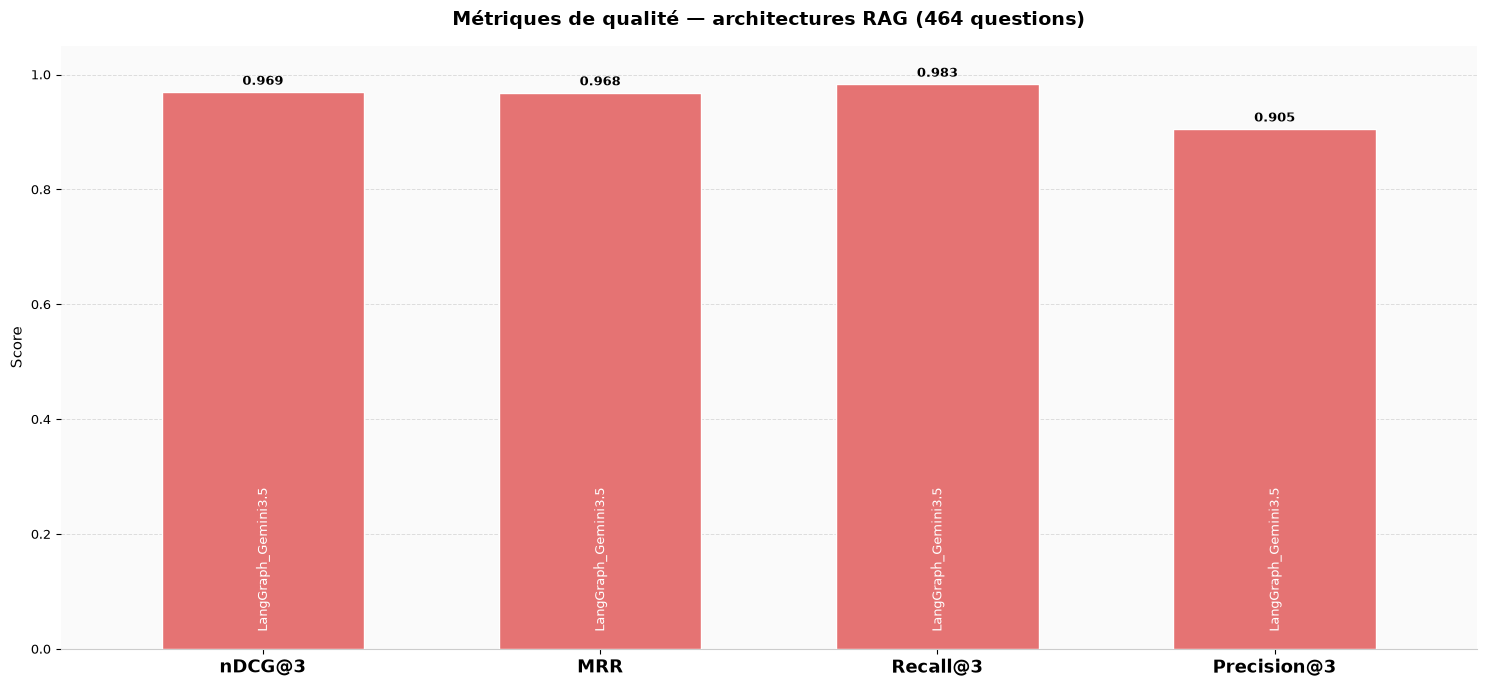

In [59]:

# ── 1. Construire le data depuis results_list ──
MODELS_DATA = build_models_data(results_list)
models = list(MODELS_DATA.keys())

# ── 2. Affichage style image : métriques de qualité côte à côte ──
plot_metrics_comparison(
    models, MODELS_DATA,
    metrics=["nDCG@3", "MRR", "Recall@3", "Precision@3"],
    title=f"Métriques de qualité — architectures RAG ({TOTAL_Q} questions)",
)


## 📈 Efficacité — tokens / latence / coût

In [60]:
# ── Tableau efficacite : tokens / latence / cout par run ────────────────────
rows_eff = []
for scen, d in MODELS_DATA.items():
    rows_eff.append({
        'Scenario':           scen,
        'Latence moy (s/q)':  d.get('Latence (s/q)', '-'),
        'LLM calls/q':        d.get('LLM calls/q', '-'),
        'Tokens LLM/q':       d.get('Tokens/q', '-'),
        'Tokens IN/q':        d.get('Tokens IN/q', '-'),
        'Tokens OUT/q':       d.get('Tokens OUT/q', '-'),
        'Tokens Think/q':     d.get('Tokens Think/q', '-'),
        'Tokens Embed/q':     d.get('Tokens Embed/q', '-'),
        'Tokens total':       f"{d['Tokens total']:,}" if d.get('Tokens total') else '-',
        'Cout estime ($)':    d.get('Cout estime ($)', d.get('Cout estime ($)', '-')),
        'nDCG@3':             d.get('nDCG@3', '-'),
        'MRR':                d.get('MRR', '-'),
    })

df_eff = pd.DataFrame(rows_eff).set_index('Scenario')
from IPython.display import display
print('=== Efficacite par run (Gemini 2.5 Flash pricing) ===')
display(df_eff)

if len(MODELS_DATA) > 1:
    plot_latency_comparison(models, MODELS_DATA,
                            title='Latence par question -- comparaison des runs')


=== Efficacite par run (Gemini 2.5 Flash pricing) ===


,Latence moy (s/q),LLM calls/q,Tokens LLM/q,Tokens IN/q,Tokens OUT/q,Tokens Think/q,Tokens Embed/q,Tokens total,Cout estime ($),nDCG@3,MRR
Scenario,,,,,,,,,,,
LangGraph_Gemini3.5,7.21,2.06,5161.3,4215.6,273.1,672.6,11.6,"2,394,838",1.4618,0.969,0.968


In [61]:
# ── Totaux absolus par run (tokens, temps) ─────────────────────────────────
rows_totals = []
for res in results_list:
    df   = res["df"]
    scen = res["scenario"]
    nb_q = len(df)

    tot_tok     = int(df["tokens_total"].sum())        if "tokens_total"       in df.columns else 0
    tot_tok_in  = int(df["tokens_in"].sum())           if "tokens_in"          in df.columns else 0
    tot_tok_out = int(df["tokens_out"].sum())          if "tokens_out"         in df.columns else 0
    tot_embed   = int(df["nb_embedded_tokens"].sum())  if "nb_embedded_tokens" in df.columns else 0
    tot_time_s  = (
        df["latency_s"].sum()
        if "latency_s" in df.columns and df["latency_s"].sum() > 0
        else res.get("total_time", 0)
    )

    rows_totals.append({
        "Scenario":           scen,
        "Questions":          nb_q,
        "Total tokens LLM":   f"{tot_tok:,}",
        "Total tokens IN":    f"{tot_tok_in:,}",
        "Total tokens OUT":   f"{tot_tok_out:,}",
        "Total tokens Embed": f"{tot_embed:,}",
        "Temps total":        f"{tot_time_s:.0f}s  ({tot_time_s/60:.1f} min)",
    })

df_totals = pd.DataFrame(rows_totals).set_index("Scenario")
print("=== Totaux absolus par run ===")
display(df_totals)


=== Totaux absolus par run ===


,Questions,Total tokens LLM,Total tokens IN,Total tokens OUT,Total tokens Embed,Temps total
Scenario,,,,,,
LangGraph_Gemini3.5,464,"2,394,838","1,956,016","126,713","5,373",3345s (55.8 min)


In [62]:
# Tarifs par modele — modifier ici pour changer le calcul de cout
MODEL_PRICING = {
    'gemini-3.5-flash': {
        'input':  1.50,   # $/1M tokens input
        'output': 9.00,   # $/1M tokens output
        'cached': 0.15,   # $/1M tokens cached input
        'think':  9.00,   # $/1M tokens thinking (= output)
        'embed':  0.01,   # $/1M tokens embedding (gemini-embedding-001)
    },
    'gemini-2.5-flash': {
        'input':  0.15,
        'output': 0.60,
        'cached': 0.0375,
        'think':  0.60,   # = output
        'embed':  0.01,
    },
    'gemini-2.5-pro': {
        'input':  1.25,
        'output': 10.00,
        'cached': 0.3125,
        'think':  10.00,  # = output
        'embed':  0.01,
    },
}

# Modele par defaut si non specifie dans results_list
DEFAULT_MODEL = 'gemini-3.5-flash'

print('Modele par defaut :', DEFAULT_MODEL)
print('Tarifs ($/1M tokens) :', MODEL_PRICING[DEFAULT_MODEL])


Modele par defaut : gemini-3.5-flash
Tarifs ($/1M tokens) : {'input': 1.5, 'output': 9.0, 'cached': 0.15, 'think': 9.0, 'embed': 0.01}


In [63]:
# Cout detaille par run — utilise MODEL_PRICING
rows_cost = []
for res in results_list:
    df        = res['df']
    scen      = res['scenario']
    model_key = res.get('model', DEFAULT_MODEL)
    pricing   = MODEL_PRICING.get(model_key, MODEL_PRICING[DEFAULT_MODEL])

    tot_in    = int(df['tokens_in'].sum())           if 'tokens_in'          in df.columns else 0
    tot_out   = int(df['tokens_out'].sum())          if 'tokens_out'         in df.columns else 0
    tot_think = int(df['tokens_think'].sum())        if 'tokens_think' in df.columns and df['tokens_think'].sum() > 0 else 0
    tot_embed = int(df['nb_embedded_tokens'].sum())  if 'nb_embedded_tokens' in df.columns else 0
    tot_llm   = int(df['llm_call_count'].sum())      if 'llm_call_count'     in df.columns else 0
    tot_tools = int(df['tool_call_count'].sum())     if 'tool_call_count'    in df.columns else 0
    tot_kong  = tot_llm + tot_tools

    cost_in    = tot_in    / 1_000_000 * pricing['input']
    cost_out   = tot_out   / 1_000_000 * pricing['output']
    cost_think = tot_think / 1_000_000 * pricing['think']
    cost_embed = tot_embed / 1_000_000 * pricing['embed']
    cost_total = cost_in + cost_out + cost_think + cost_embed

    rows_cost.append({
        'Scenario':           scen,
        'Modele':             model_key,
        'LLM calls (total)':  tot_llm,
        'Tool calls (total)': tot_tools,
        'Kong requests':      tot_kong,
        'Cout IN ($)':        round(cost_in,    4),
        'Cout OUT ($)':       round(cost_out,   4),
        'Cout Think ($)':     round(cost_think, 4),
        'Cout Embed ($)':     round(cost_embed, 4),
        'Cout total ($)':     round(cost_total, 4),
    })

df_cost = pd.DataFrame(rows_cost).set_index('Scenario')
print('=== Cout detaille par run ===')
for mk in df_cost['Modele'].unique():
    p = MODEL_PRICING.get(mk, {})
    print(f"  {mk}: IN=${p.get('input',0)}/1M  OUT=${p.get('output',0)}/1M  Think=${p.get('think',0)}/1M  Embed=${p.get('embed',0)}/1M")
display(df_cost.drop(columns=['Modele']))


=== Cout detaille par run ===
  gemini-3.5-flash: IN=$1.5/1M  OUT=$9.0/1M  Think=$9.0/1M  Embed=$0.01/1M


,LLM calls (total),Tool calls (total),Kong requests,Cout IN ($),Cout OUT ($),Cout Think ($),Cout Embed ($),Cout total ($)
Scenario,,,,,,,,
LangGraph_Gemini3.5,958,495,1453,2.934,1.1404,2.809,0.0001,6.8835


## 📊 Cellule 7 — Calcul des Métriques

In [64]:
# golden_map = {item['id']: item for item in GOLDEN_DATASET}

# all_results = []
# errors      = []

# for row in raw_results:
#     qid    = str(row.get('id', ''))
#     answer = str(row.get('output', ''))

#     if qid not in golden_map:
#         errors.append({'id': qid, 'error': 'ID non trouvé dans Golden Dataset'})
#         continue

#     item      = golden_map[qid]
#     expected  = item.get('expected_apis', [])
#     retrieved = extract_apis(answer)
#     is_neg    = (len(expected) == 0)
#     strict    = (item.get('category') == 'versioning')   # version exacte sur versioning
#     # strict    = True   # version exacte sur versioning

#     mrr = mrr_score(retrieved, expected, strict=strict)

#     all_results.append({
#         'id'         : qid,
#         'question'   : item['question'],
#         'category'   : item.get('category', 'simple'),
#         'difficulty' : item.get('difficulty', 'easy'),
#         'domain'     : item.get('domain', 'unknown'),
#         'expected'   : expected,
#         'retrieved'  : retrieved,
#         'answer'     : answer,
#         'is_negative': is_neg,
#         'mrr'        : mrr,
#         'recall'     : recall_at_k(retrieved, expected, TOP_K, strict=strict),
#         'precision'  : precision_at_k(retrieved, expected, TOP_K, strict=strict),
#         'ndcg' : ndcg_at_k(retrieved, expected, 5, strict=strict),
#         'hit'        : 1 if mrr > 0 else 0,
#     })

# df = pd.DataFrame(all_results)

# # Métriques principales : on EXCLUT les négatives (mrr/recall/precision n'ont pas de sens dessus)
# df_pos = df[~df['is_negative']]
# avg_mrr  = df_pos['mrr'].mean()
# avg_rec  = df_pos['recall'].mean()
# avg_prec = df_pos['precision'].mean()
# avg_ndcg = df_pos['ndcg'].mean()
# hit_rate = df_pos['hit'].mean()

# # Specificity : uniquement sur les négatives (a-t-on bien répondu AUCUNE_API ?)
# df_neg = df[df['is_negative']]
# specificity = df_neg['hit'].mean() if len(df_neg) else float('nan')

# lat_moy = total_time / len(all_results) if all_results else 0

# print('=' * 64)
# print(f'  RÉSULTATS — {SCENARIO}')
# print('=' * 64)
# print(f'  Questions     : {len(all_results)} ({len(df_pos)} positives + {len(df_neg)} négatives) | Erreurs : {len(errors)}')
# print(f'  Exec n8n      : 1 (Fire & Forget)')
# print(f'  Temps total   : {total_time:.0f}s ({total_time/60:.1f} min)')
# print(f'  Latence moy   : {lat_moy:.2f}s/question')
# print('-' * 64)
# print(f'  {"Métrique":<26} {"Valeur":>10}')
# print('-' * 64)
# print(f'  {"MRR":<26} {avg_mrr:>10.3f}')
# print(f'  {"Recall@3":<26} {avg_rec:>10.3f}')
# print(f'  {"Precision@3":<26} {avg_prec:>10.3f}')
# print(f'  {"nDCG@3":<26} {avg_ndcg:>10.3f}')
# print(f'  {"Hit Rate":<26} {hit_rate:>10.3f}')
# print(f'  {"Specificity (négatives)":<26} {specificity:>10.3f}')
# print('=' * 64)

# # Breakdown par catégorie — très utile pour discuter avec Marc
# print('\n  Détail par catégorie (hors négatives) :')
# print(f'  {"Catégorie":<14} {"n":>4} {"MRR":>8} {"Recall@3":>10} {"Prec@3":>8} {"Hit":>6}')
# for cat, grp in df_pos.groupby('category'):
#     print(f'  {cat:<14} {len(grp):>4} {grp["mrr"].mean():>8.3f} '
#           f'{grp["recall"].mean():>10.3f} {grp["precision"].mean():>8.3f} {grp["hit"].mean():>6.3f}')

# #=========================================================
# print()
# print('"' + SCENARIO + '": {')
# print(f'    "nickname": "{SCENARIO}", "color": "#E57373",')
# print(f'    "nDCG@3": {avg_ndcg:.3f}, "MRR": {avg_mrr:.3f}, "Recall@3": {avg_rec:.3f}, "Precision@3": {avg_prec:.3f},')
# print(f'    "Specificity": {specificity:.3f}, "Latence (s/q)": {lat_moy:.2f}, "Temps Total (s)": {total_time:.0f},')
# print('},')




## Cellule 7bis

In [65]:
from IPython.display import display

LABEL_SCORE = {2: 'OK', 1: 'Partiel', 0: 'Faux'}

def score_question(expected, retrieved, strict=False):
    if len(expected) == 0:
        return 2 if len(retrieved) == 0 else 0
    nb = sum(1 for e in expected if any(is_match(r, e, strict=strict) for r in retrieved))
    return 2 if nb == len(expected) else (0 if nb == 0 else 1)


def show_details(results_list, mode='both',
                 download_full=False, download_echec=False):
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_rows', None)

    for res in results_list:
        df = res['df']
        lignes = []
        for _, row in df.iterrows():
            strict = (row['category'] == 'versioning')
            sc = score_question(row['expected'], row['retrieved'], strict=strict)
            na = len(row['expected'])
            nt = sum(1 for e in row['expected']
                     if any(is_match(r, e, strict=strict) for r in row['retrieved'])) if na else 0
            lignes.append({
                'id':           row['id'],
                'category':     row['category'],
                'question':     row['question'][:70],
                'expected':     ', '.join(row['expected']) or '(aucune)',
                'retrieved':    ', '.join(row['retrieved']) or '(aucune)',
                'trouvees':     f'{nt}/{na}' if na else f'0/0 (+{len(row["retrieved"])})',
                'score':        sc,
                'verdict':      LABEL_SCORE[sc],
                'latency_s':    round(float(row.get('latency_s',        0)), 2),
                'llm_calls':    int(row.get('llm_call_count',            0)),
                'tool_calls':   int(row.get('tool_call_count',           0)),
                'tokens_in':    int(row.get('tokens_in',                 0)),
                'tokens_out':   int(row.get('tokens_out',                0)),
                'tokens_total': int(row.get('tokens_total',              0)),
                'tokens_embed': int(row.get('nb_embedded_tokens',        0)),
            })
        df_detail = pd.DataFrame(lignes)
        df_detail_echec = df_detail[df_detail['score'] < 2].copy()

        res['df_detail']       = df_detail
        res['df_detail_echec'] = df_detail_echec

        avg_lat   = df_detail['latency_s'].mean()
        avg_llm   = df_detail['llm_calls'].mean()
        avg_tools = df_detail['tool_calls'].mean()
        avg_in    = df_detail['tokens_in'].mean()
        avg_out   = df_detail['tokens_out'].mean()
        print(f"\n{'='*70}")
        print(f"  {res['scenario']}")
        print(f"  {len(df_detail_echec)} echecs / {len(df_detail)} questions")
        print(f"  Latence moy : {avg_lat:.2f}s  |  LLM calls/q : {avg_llm:.1f}  |  Tool calls/q : {avg_tools:.1f}")
        print(f"  Tokens IN/q : {avg_in:.0f}   |  Tokens OUT/q : {avg_out:.0f}")
        print(f"{'='*70}")

        cols_show = ['id', 'category', 'verdict', 'trouvees',
                     'latency_s', 'llm_calls', 'tool_calls',
                     'tokens_in', 'tokens_out', 'tokens_embed',
                     'question', 'expected', 'retrieved']

        if mode in ('full', 'both'):
            print('\n--- Toutes les questions ---')
            display(df_detail[cols_show].head(10))

        if mode in ('echec', 'both'):
            print('\n--- Echecs uniquement (score < 2) ---')
            display(df_detail_echec[cols_show])

        if download_full:
            fname = res.get('title_results', f"{res['scenario']}_full.xlsx")
            df_detail.to_excel(fname, index=False, engine='openpyxl')
            if IN_COLAB:
                from google.colab import files; files.download(fname)
        if download_echec:
            fname = res.get('title_results_echec', f"{res['scenario']}_echec.xlsx")
            df_detail_echec.to_excel(fname, index=False, engine='openpyxl')
            if IN_COLAB:
                from google.colab import files; files.download(fname)

    return results_list


In [66]:
# Les 4 displays (full + échec pour chacun des 2 onglets) — comme ton affichage précédent
cs = show_details(results_list , mode="full")


  LangGraph_Gemini3.5
  12 echecs / 464 questions
  Latence moy : 7.21s  |  LLM calls/q : 2.1  |  Tool calls/q : 1.1
  Tokens IN/q : 4216   |  Tokens OUT/q : 273

--- Toutes les questions ---


,id,category,verdict,trouvees,latency_s,llm_calls,tool_calls,tokens_in,tokens_out,tokens_embed,question,expected,retrieved
0,Q0001,simple,OK,1/1,12.28,2,1,4034,262,5,URGENT faut creer une commande client jen ai besoin la tout de suite c,order-api-v4,order-api-v4
1,Q0002,simple,OK,1/1,9.94,2,1,4141,274,9,"je veux fetch le profil du user qui vient de se log, quelle api ?",auth-api,"auth-api, profile-api"
2,Q0003,simple,OK,1/1,14.24,3,2,9165,235,25,"Salut, je bosse sur le nouveau site e-commerce de ma boite et le PO ve",search-api-v3,search-api-v3
3,Q0004,simple,OK,1/1,7.40,2,1,4114,239,8,URGENT faut alerter auto qd le stock dun produit passe sous le seuil m,inventory-api,inventory-api
4,Q0005,simple,OK,1/1,7.31,2,1,3996,295,5,"Je dois afficher le prix d'un produit avec les promos appliquées, quel",pricing-api,pricing-api
5,Q0006,simple,OK,1/1,9.96,2,1,4141,274,9,"je veux fetch le profil du user qui vient de se log, quelle api ?",auth-api,"auth-api, profile-api"
6,Q0007,simple,OK,1/1,5.35,2,1,4060,183,5,"le user clique sur 'add to cart', japelle quelle api ?",cart-api,cart-api
7,Q0008,simple,OK,1/1,10.61,2,1,4005,404,6,"besoin denvoyer une notif push qd la commande est shippée, vite cest p",notification-api-v3,"push-api, notification-api-v3"
8,Q0009,simple,OK,1/1,9.36,2,1,4049,329,6,"Bonjour, on a plein de clients qui nous appellent pour savoir où est l",logistics-tracking-api,"logistics-tracking-api, shipping-api-v2"
9,Q0010,simple,OK,1/1,6.09,2,1,4097,214,7,jveux permettre aux clients de laisser une note et un commentaire sur,review-api,review-api


In [67]:
# Les 4 displays (full + échec pour chacun des 2 onglets) — comme ton affichage précédent
cs = show_details(results_list , mode="full")


  LangGraph_Gemini3.5
  12 echecs / 464 questions
  Latence moy : 7.21s  |  LLM calls/q : 2.1  |  Tool calls/q : 1.1
  Tokens IN/q : 4216   |  Tokens OUT/q : 273

--- Toutes les questions ---


,id,category,verdict,trouvees,latency_s,llm_calls,tool_calls,tokens_in,tokens_out,tokens_embed,question,expected,retrieved
0,Q0001,simple,OK,1/1,12.28,2,1,4034,262,5,URGENT faut creer une commande client jen ai besoin la tout de suite c,order-api-v4,order-api-v4
1,Q0002,simple,OK,1/1,9.94,2,1,4141,274,9,"je veux fetch le profil du user qui vient de se log, quelle api ?",auth-api,"auth-api, profile-api"
2,Q0003,simple,OK,1/1,14.24,3,2,9165,235,25,"Salut, je bosse sur le nouveau site e-commerce de ma boite et le PO ve",search-api-v3,search-api-v3
3,Q0004,simple,OK,1/1,7.40,2,1,4114,239,8,URGENT faut alerter auto qd le stock dun produit passe sous le seuil m,inventory-api,inventory-api
4,Q0005,simple,OK,1/1,7.31,2,1,3996,295,5,"Je dois afficher le prix d'un produit avec les promos appliquées, quel",pricing-api,pricing-api
5,Q0006,simple,OK,1/1,9.96,2,1,4141,274,9,"je veux fetch le profil du user qui vient de se log, quelle api ?",auth-api,"auth-api, profile-api"
6,Q0007,simple,OK,1/1,5.35,2,1,4060,183,5,"le user clique sur 'add to cart', japelle quelle api ?",cart-api,cart-api
7,Q0008,simple,OK,1/1,10.61,2,1,4005,404,6,"besoin denvoyer une notif push qd la commande est shippée, vite cest p",notification-api-v3,"push-api, notification-api-v3"
8,Q0009,simple,OK,1/1,9.36,2,1,4049,329,6,"Bonjour, on a plein de clients qui nous appellent pour savoir où est l",logistics-tracking-api,"logistics-tracking-api, shipping-api-v2"
9,Q0010,simple,OK,1/1,6.09,2,1,4097,214,7,jveux permettre aux clients de laisser une note et un commentaire sur,review-api,review-api


In [68]:
cs = show_details(results_list , mode="echec")


  LangGraph_Gemini3.5
  12 echecs / 464 questions
  Latence moy : 7.21s  |  LLM calls/q : 2.1  |  Tool calls/q : 1.1
  Tokens IN/q : 4216   |  Tokens OUT/q : 273

--- Echecs uniquement (score < 2) ---


,id,category,verdict,trouvees,latency_s,llm_calls,tool_calls,tokens_in,tokens_out,tokens_embed,question,expected,retrieved
71,Q0072,faux_positif,Faux,0/1,20.57,2,1,4113,245,9,"Je veux faire un virement vers un fournisseur externe, c'est pas le mê",payout-api,transfer-api-v2
120,Q0121,faux_positif,Faux,0/1,10.05,2,1,3976,323,6,Je gère une flotte de véhicules mais c'est pas les trajets que je veux,fleet-api-v4,vehicle-api-v2
243,Q0244,simple,Faux,0/1,9.33,4,3,10648,46,56,Je veux louer une salle de séminaire pour 100 personnes avec traiteur,event-venue-api,(aucune)
322,Q0323,simple,Faux,0/1,17.24,3,2,7349,286,13,"je dois envoyer des SMS OTP en masse avec gestion des opt-out, quelle",sms-api,notification-api-v2
419,Q0420,multi_api,Partiel,1/2,8.60,2,1,3939,326,10,Je dois déployer une mise à jour firmware sur mes capteurs ET suivre l,"firmware-api, sensor-data-api-v2","firmware-api, device-registry-api"
425,Q0426,multi_api,Partiel,1/2,6.72,2,1,3971,225,6,Je dois analyser le sol d'une parcelle ET recommander un plan de ferti,"soil-analysis-api, fertilizer-api",soil-analysis-api
427,Q0428,multi_api,Partiel,1/2,7.82,2,1,3995,330,11,Je veux détecter une vulnérabilité ET créer automatiquement un inciden,"vulnerability-api-v2, security-incident-api-v2","vulnerability-scanner-api, security-incident-api-v2"
429,Q0430,multi_api,Partiel,1/2,8.84,2,1,3987,332,9,Je veux créer une vente flash ET envoyer une notification push à tous,"flash-sale-api, notification-api-v3","flash-sale-api, push-api"
433,Q0434,multi_api,Partiel,1/3,8.63,2,1,4029,325,16,Je veux envoyer une notification email + push + SMS coordonnés depuis,"notification-api-v3, email-api, sms-api",notification-api-v3
446,Q0447,negative,Faux,0/0 (+1),6.65,3,2,7014,353,26,Je veux une API pour calculer les algorithmes de trading haute fréquen,(aucune),trading-api-v2


In [69]:
def show_echecs_communs(results_list, mode="echec"):
    """
    Affiche les questions en échec (score < 2) sur TOUTES les versions de results_list.
    Suppose que show_details() a déjà été appelé (df_detail / df_detail_echec présents).
    mode : "echec" → un id est commun s'il est en échec partout (score < 2)
           "faux"  → un id est commun s'il est faux partout (score == 0)
    """
    seuil = 0 if mode == "faux" else 1  # score <= seuil compte comme échec

    # Ensemble des ids en échec pour chaque version, puis intersection
    sets_echec = []
    for res in results_list:
        if 'df_detail' not in res:
            raise ValueError("Lance d'abord show_details() pour calculer df_detail.")
        ids = set(res['df_detail'].loc[res['df_detail']['score'] <= seuil, 'id'])
        sets_echec.append(ids)

    ids_communs = set.intersection(*sets_echec) if sets_echec else set()

    print(f"\n{'='*70}")
    label = "FAUX (score 0)" if mode == "faux" else "EN ÉCHEC (score < 2)"
    print(f"  {len(ids_communs)} questions {label} sur TOUTES les {len(results_list)} versions")
    print(f"{'='*70}")

    if not ids_communs:
        print("Aucune question en échec sur toutes les versions 🎉")
        return pd.DataFrame()

    # Tableau récap : une ligne par id, une colonne score par version
    ref = results_list[0]['df_detail']
    recap = ref[ref['id'].isin(ids_communs)][['id', 'category', 'question', 'expected']].copy()

    for res in results_list:
        d = res['df_detail'].set_index('id')
        recap[res['scenario']] = recap['id'].map(d['score'])

    recap = recap.sort_values('id').reset_index(drop=True)
    display(recap)
    return recap

In [70]:
# show_echecs_communs(results_list)              # échec (score < 2) partout
recap = show_echecs_communs(results_list, mode="echec") # faux dur (score 0) partout


  12 questions EN ÉCHEC (score < 2) sur TOUTES les 1 versions


,id,category,question,expected,LangGraph_Gemini3.5
0,Q0072,faux_positif,"Je veux faire un virement vers un fournisseur externe, c'est pas le mê",payout-api,0
1,Q0121,faux_positif,Je gère une flotte de véhicules mais c'est pas les trajets que je veux,fleet-api-v4,0
2,Q0244,simple,Je veux louer une salle de séminaire pour 100 personnes avec traiteur,event-venue-api,0
3,Q0323,simple,"je dois envoyer des SMS OTP en masse avec gestion des opt-out, quelle",sms-api,0
4,Q0420,multi_api,Je dois déployer une mise à jour firmware sur mes capteurs ET suivre l,"firmware-api, sensor-data-api-v2",1
5,Q0426,multi_api,Je dois analyser le sol d'une parcelle ET recommander un plan de ferti,"soil-analysis-api, fertilizer-api",1
6,Q0428,multi_api,Je veux détecter une vulnérabilité ET créer automatiquement un inciden,"vulnerability-api-v2, security-incident-api-v2",1
7,Q0430,multi_api,Je veux créer une vente flash ET envoyer une notification push à tous,"flash-sale-api, notification-api-v3",1
8,Q0434,multi_api,Je veux envoyer une notification email + push + SMS coordonnés depuis,"notification-api-v3, email-api, sms-api",1
9,Q0447,negative,Je veux une API pour calculer les algorithmes de trading haute fréquen,(aucune),0
